<table width="100%" cellpadding="0" cellspacing="0" style="border-collapse:separate;border-spacing:0;border-radius:18px;overflow:hidden;border:1px solid rgba(148,163,184,0.35);">
  <tr>
    <td style="background:linear-gradient(135deg,#f7fbff 0%,#edf3fb 38%,#f3f6ff 62%,#fff3ed 100%);padding:0;">
      <div style="height:4px;background:linear-gradient(90deg,#0EA5E9 0%,#F97316 55%,#6366F1 100%);">
 </div>
      <div style="padding:24px 28px;text-align:center;color:#0b1535;">

        
   <div style="display:inline-block;padding:6px 12px;border-radius:999px;border:1px solid rgba(15,23,42,0.18);color:rgba(15,23,42,0.78);font-size:12px;font-weight:700;margin-bottom:12px;background:rgba(255,255,255,0.85);">
          Decision-Support Analytics • OSMI Tech Mental Health
        </div>

 <div style="font-size:30px;font-weight:900;line-height:1.12;margin:0 0 10px;">
          <span style="color:#0EA5E9;">SupportScore</span>
          <span style="color:#0b1535;"> × </span>
          <span style="color:#F97316;">StigmaScore</span>
          <span style="color:#0b1535;"> — From Survey Data to Operational Insight</span>
        </div>

<div style="font-size:16px;font-weight:650;color:rgba(15,23,42,0.86);">
          Demographics • Workplace analytics • KPI &amp; segmentation • Evidence-based modeling
        </div>

 <div style="font-size:13px;margin-top:10px;color:rgba(15,23,42,0.68);">
          Treatment prevalence • Work interference risk • Actionable, executive-ready insights
        </div>

  </div>
    </td>
  </tr>
</table>

![cover](https://raw.githubusercontent.com/rbyzk/MachineLearningProjects/main/Tech_Mental_Health/mental_health.png)

<div style="
    border:1px solid #E5E7EB;
    border-radius:14px;
    padding:16px 18px;
    background:#FFFFFF;
    font-size:15px;
    line-height:1.55;
    color:#0F172A;">

<h3 style="margin:0 0 8px 0; font-weight:700; color:#0F172A;">
OSMI Tech Mental Health — Analytical Scope & Objectives
</h3>

<p style="margin-top:2px;">
This notebook uses the OSMI Tech Mental Health survey to quantify support mechanisms (SupportScore) 
and stigma dynamics (StigmaScore) across the technology workforce, and connects these constructs to 
treatment uptake, work interference, and organisational policy maturity.
</p>

<p>
The intent is to deliver decision-support across three analytical layers:
</p>

<ul>
<li><b>Diagnostic analytics:</b> Where are treatment, support, and work interference concentrated across demographics and countries?</li>
<li><b>Segmentation and personas:</b> How do Support × Stigma quadrants translate into actionable employee segments for policy instruments vs culture- and manager-led interventions?</li>
<li><b>Predictive modeling:</b> Which factors most strongly drive treatment probability, and where do support levers (benefits, care options, anonymity, leave clarity, etc.) shift risk at scale?</li>
</ul>

<p>
The notebook concludes with an <b>executive-ready action plan</b> focused on policy standardisation, 
stigma reduction, trust and anonymity reinforcement, and proactive monitoring of high work-interference 
segments as an operational risk signal.
</p>

</div>


# **Imports & Environment Setup**

In [1]:
import os, re, io, uuid, base64
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LinearSegmentedColormap

from IPython.display import HTML, display

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

THEME = {
    "slate": "#0F172A",
    "gray": "#475569",
    "muted": "rgba(15,23,42,.10)",
    "blue": "#0EA5E9",
    "orange": "#F97316",
    "purple": "#7C3AED",
    "red": "#E11D48",
    "bg": "#FFFFFF",
    "grid_a": 0.10,
}

plt.rcParams.update({
    "figure.facecolor": THEME["bg"],
    "axes.facecolor": THEME["bg"],
    "axes.labelcolor": THEME["slate"],
    "xtick.color": THEME["slate"],
    "ytick.color": THEME["slate"],
    "text.color": THEME["slate"],
    "font.size": 11,
})

CMAP_BO = LinearSegmentedColormap.from_list(
    "BlueOrange",
    [THEME["blue"], "#FFFFFF", THEME["orange"]],
    N=256
)

In [2]:
def section(title, subtitle=None):
    sub = f"<div style='color:{THEME['gray']};font-weight:850;margin-top:4px'>{subtitle}</div>" if subtitle else ""
    display(HTML(f"""
    <div style="margin:18px 0 10px 0">
      <div style="font-size:18px;font-weight:1000;color:{THEME['slate']}">{title}</div>
      {sub}
    </div>
    """))

def ax_minimal(ax, grid_axis="y"):
    for s in ["top", "right", "left", "bottom"]:
        ax.spines[s].set_visible(False)
    ax.grid(axis=grid_axis, linestyle="-", alpha=THEME["grid_a"])
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="both", length=0)

def clean_str(s: pd.Series) -> pd.Series:
    return s.astype("string").str.replace(r"\s+", " ", regex=True).str.strip()

def as_yes_no(s: pd.Series) -> pd.Series:
    x = clean_str(s).str.lower()
    m = {"yes":"Yes","y":"Yes","true":"Yes","1":"Yes","no":"No","n":"No","false":"No","0":"No"}
    return x.map(m).fillna(clean_str(s))

def style_table(sty):
    sty = sty.set_table_styles([
        {"selector":"th", "props":[("font-weight","1000"), ("font-size","12px"), ("background-color","#F8FAFC")]},
        {"selector":"td", "props":[("font-size","12px")]},
    ])
    if hasattr(sty, "hide_index"):
        sty = sty.hide_index()
    return sty

def show_df(df, title=None, precision=3, cmap="BlueOrange", max_rows=14):
    d = df.copy().head(max_rows)
    sty = d.style.format(precision=precision)
    if cmap == "BlueOrange":
        sty = sty.background_gradient(cmap=CMAP_BO, axis=None)
    elif cmap:
        sty = sty.background_gradient(cmap=cmap, axis=None)
    sty = style_table(sty)
    cap = f"<div style='font-weight:1000;margin:10px 0 6px 0;color:{THEME['slate']}'>{title}</div>" if title else ""
    return HTML(cap + sty.to_html())

def df_tabs(tables, panel_title=None):
    panel_id = "dftabs_" + uuid.uuid4().hex[:8]
    btns, panes = [], []
    for i, (label, dfx, precision, cmap, max_rows) in enumerate(tables):
        active = "active" if i == 0 else ""
        pid = f"{panel_id}_p{i}"
        btns.append(f"<button class='dt-tab {active}' onclick=\"openDT_{panel_id}(event,'{pid}')\">{label}</button>")
        body = show_df(dfx, title=None, precision=precision, cmap=cmap, max_rows=max_rows).data
        panes.append(f"<div class='dt-pane {active}' id='{pid}'>{body}</div>")
    title_html = f"<div class='dt-title'>{panel_title}</div>" if panel_title else ""
    html = f"""
    <div id="{panel_id}" class="dt-wrap">
      {title_html}
      <div class="dt-tabs">{''.join(btns)}</div>
      <div class="dt-content">{''.join(panes)}</div>
    </div>
    <style>
      #{panel_id}.dt-wrap {{ margin-top:10px;border:1px solid {THEME["muted"]};border-radius:14px;overflow:hidden;background:#fff; }}
      #{panel_id} .dt-title {{ padding:12px 14px 0 14px;font-weight:1000;font-size:14px;color:{THEME["slate"]}; }}
      #{panel_id} .dt-tabs {{ display:flex;flex-wrap:wrap;gap:8px;padding:12px;border-bottom:1px solid {THEME["muted"]}; }}
      #{panel_id} .dt-tab {{
        appearance:none;border:1px solid rgba(15,23,42,.18);background:#fff;color:{THEME["slate"]};
        font-weight:1000;font-size:12px;padding:7px 10px;border-radius:10px;cursor:pointer;line-height:1.1;
      }}
      #{panel_id} .dt-tab.active {{ background: rgba(14,165,233,.10); border-color: rgba(14,165,233,.35); }}
      #{panel_id} .dt-content {{ padding:12px; max-width:100%; overflow-x:auto; }}
      #{panel_id} .dt-pane {{ display:none; }}
      #{panel_id} .dt-pane.active {{ display:block; }}
    </style>
    <script>
      function openDT_{panel_id}(evt, paneId) {{
        const root = document.getElementById("{panel_id}");
        const panes = root.getElementsByClassName("dt-pane");
        for (let i=0;i<panes.length;i++) panes[i].classList.remove("active");
        const tabs = root.getElementsByClassName("dt-tab");
        for (let i=0;i<tabs.length;i++) tabs[i].classList.remove("active");
        document.getElementById(paneId).classList.add("active");
        evt.currentTarget.classList.add("active");
      }}
    </script>
    """
    display(HTML(html))

def kpi_cards(cards, panel_id=None):
    if panel_id is None:
        panel_id = "kpi_" + uuid.uuid4().hex[:8]
    items = []
    for c in cards:
        items.append(f"""
        <div class="kpi-card">
          <div class="kpi-title">{c.get("title","")}</div>
          <div class="kpi-value" style="color:{c.get("accent",THEME["blue"])}">{c.get("value","")}</div>
          <div class="kpi-sub">{c.get("sub","")}</div>
        </div>
        """)
    html = f"""
    <div id="{panel_id}" class="kpi-wrap">{''.join(items)}</div>
    <style>
      #{panel_id}.kpi-wrap {{
        display:grid; grid-template-columns: repeat(4, minmax(0,1fr));
        gap:14px; margin: 10px 0 10px 0;
      }}
      @media (max-width: 980px) {{ #{panel_id}.kpi-wrap {{ grid-template-columns: 1fr; }} }}
      #{panel_id} .kpi-card {{
        background:#fff; border:1px solid {THEME["muted"]};
        border-radius:14px; padding:14px 16px;
      }}
      #{panel_id} .kpi-title {{ font-size:12px; font-weight:1000; color:{THEME["slate"]}; letter-spacing:.2px; }}
      #{panel_id} .kpi-value {{ margin-top:6px; font-size:34px; font-weight:1000; line-height:1; }}
      #{panel_id} .kpi-sub {{ margin-top:6px; font-size:12px; font-weight:850; color:{THEME["gray"]}; }}
    </style>
    """
    return HTML(html)

def fig_to_b64(fig, dpi=130, prefer="webp"):
    buf = io.BytesIO()
    fmt = prefer
    try:
        fig.savefig(buf, format=fmt, dpi=dpi, bbox_inches="tight", facecolor="white")
    except Exception:
        fmt = "png"
        buf = io.BytesIO()
        fig.savefig(buf, format=fmt, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
    mime = "image/webp" if fmt == "webp" else "image/png"
    return b64, mime

def chart_tabs(charts, panel_title=None):
    panel_id = "ctabs_" + uuid.uuid4().hex[:8]
    btns, panes = [], []
    for i, (label, b64, mime, caption) in enumerate(charts):
        active = "active" if i == 0 else ""
        pid = f"{panel_id}_p{i}"
        btns.append(f"<button class='ct-tab {active}' onclick=\"openCT_{panel_id}(event,'{pid}')\">{label}</button>")
        cap_html = f"<div class='ct-cap'>{caption}</div>" if caption else ""
        panes.append(
            f"<div class='ct-pane {active}' id='{pid}'>"
            f"<img src='data:{mime};base64,{b64}' style='max-width:100%;height:auto;display:block;'/>"
            f"{cap_html}</div>"
        )
    title_html = f"<div class='ct-title'>{panel_title}</div>" if panel_title else ""
    html = f"""
    <div id="{panel_id}" class="ct-wrap">
      {title_html}
      <div class="ct-tabs">{''.join(btns)}</div>
      <div class="ct-content">{''.join(panes)}</div>
    </div>
    <style>
      #{panel_id}.ct-wrap {{ margin-top:10px;border:1px solid {THEME["muted"]};border-radius:14px;overflow:hidden;background:#fff; }}
      #{panel_id} .ct-title {{ padding:12px 14px 0 14px;font-weight:1000;font-size:14px;color:{THEME["slate"]}; }}
      #{panel_id} .ct-tabs {{ display:flex;flex-wrap:wrap;gap:8px;padding:12px;border-bottom:1px solid {THEME["muted"]}; }}
      #{panel_id} .ct-tab {{
        appearance:none;border:1px solid rgba(15,23,42,.18);background:#fff;color:{THEME["slate"]};
        font-weight:1000;font-size:12px;padding:7px 10px;border-radius:10px;cursor:pointer;line-height:1.1;
      }}
      #{panel_id} .ct-tab.active {{ background: rgba(249,115,22,.12); border-color: rgba(249,115,22,.35); }}
      #{panel_id} .ct-content {{ padding:14px; }}
      #{panel_id} .ct-pane {{ display:none; }}
      #{panel_id} .ct-pane.active {{ display:block; }}
      #{panel_id} .ct-cap {{ margin-top:8px;color:{THEME["gray"]};font-size:12px;font-weight:850; }}
    </style>
    <script>
      function openCT_{panel_id}(evt, paneId) {{
        const root = document.getElementById("{panel_id}");
        const panes = root.getElementsByClassName("ct-pane");
        for (let i=0;i<panes.length;i++) panes[i].classList.remove("active");
        const tabs = root.getElementsByClassName("ct-tab");
        for (let i=0;i<tabs.length;i++) tabs[i].classList.remove("active");
        document.getElementById(paneId).classList.add("active");
        evt.currentTarget.classList.add("active");
      }}
    </script>
    """
    display(HTML(html))

# **1. Data Loading**

This section ingests the raw OSMI Tech Mental Health survey, standardizes column names, and provides a quick structural snapshot (rows, columns, basic missingness, and sample records).

In [3]:
DATA_PATH = "/kaggle/input/mental-health-in-tech-survey/survey.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df.columns = (df.columns.str.strip().str.lower()
              .str.replace("[^a-z0-9]+", "_", regex=True)
              .str.replace("_+$", "", regex=True))

meta = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Duplicates", "Missingness (cells, %)"],
    "Value": [
        float(df.shape[0]),
        float(df.shape[1]),
        float(df.duplicated().sum()),
        round(df.isna().sum().sum() / (df.shape[0]*df.shape[1]) * 100, 2),
    ]
})

cols_df = pd.DataFrame({"column": df.columns})
sample_df = df.sample(8, random_state=42) if len(df) >= 8 else df.copy()

df_tabs([
    ("Sample", sample_df, 3, "BlueOrange", 8),
    ("Snapshot", meta, 2, "BlueOrange", 10),
    ("Columns", cols_df, 0, "Blues", 120),
], panel_title="Dataset")

# **2. Data Quality** 

Here we assess data fitness for decision-support by profiling missingness and checking the validity of the key outcome fields, especially treatment and work interference.

In [4]:
missing = (df.isna().sum().rename("missing_count").reset_index().rename(columns={"index":"column"}))
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(1)
missing = missing.sort_values("missing_pct", ascending=False)

d0 = df.copy()
d0["treatment"] = as_yes_no(d0["treatment"]) if "treatment" in d0.columns else "NA"
valid_treat_n = int(d0["treatment"].isin(["Yes","No"]).sum())
valid_treat_ratio = float(d0["treatment"].isin(["Yes","No"]).mean())

validity = pd.DataFrame([{
    "treatment_valid_ratio": round(valid_treat_ratio, 3),
    "treatment_valid_n": valid_treat_n,
    "work_interfere_missing_pct": round(float(df["work_interfere"].isna().mean()*100), 1) if "work_interfere" in df.columns else np.nan,
}])

df_tabs([
    ("Missing (Top 15)", missing.head(15), 1, "Blues", 15),
    ("Validity", validity, 3, "BlueOrange", 8),
], panel_title="Data Quality")

,column,missing_count,missing_pct
26,comments,1095,87.0
4,state,515,40.9
8,work_interfere,264,21.0
5,self_employed,18,1.4
2,gender,0,0.0
0,timestamp,0,0.0
1,age,0,0.0
6,family_history,0,0.0
7,treatment,0,0.0
9,no_employees,0,0.0


# **3. Feature Engineering**

SupportScore and StigmaScore are constructed, core survey fields (age, gender, country) are cleaned, and numeric encodings (e.g., work_interfere_y) are derived to support KPI calculation, segmentation, and predictive modeling.

In [5]:
d = df.copy()

d["treatment"] = as_yes_no(d["treatment"]) if "treatment" in d.columns else "NA"
d["work_interfere"] = clean_str(d["work_interfere"]).replace("", np.nan).fillna("NA") if "work_interfere" in d.columns else "NA"

support_cols = [c for c in ["benefits","care_options","seek_help","wellness_program","anonymity","leave"] if c in d.columns]
for c in support_cols:
    d[c] = clean_str(d[c]).replace("", np.nan).fillna("NA")
    d[c+"_sup"] = d[c].str.lower().eq("yes").astype("Int64")

d["SupportScore"] = d[[c+"_sup" for c in support_cols]].sum(axis=1).astype("float") if support_cols else np.nan

stigma_cols = [c for c in ["mental_vs_physical","coworkers","supervisor","obs_consequence"] if c in d.columns]
for c in stigma_cols:
    d[c] = clean_str(d[c]).replace("", np.nan).fillna("NA")

def stigma_points(colname, s: pd.Series) -> pd.Series:
    x = s.astype("string").str.lower().str.strip()
    if colname == "mental_vs_physical":
        m = {"yes":0.0, "no":1.0, "dont know":0.75, "don't know":0.75, "na":0.75}
        return x.map(m).fillna(0.75)
    if colname in ["coworkers","supervisor"]:
        m = {"yes":0.0, "some of them":0.5, "no":1.0, "dont know":0.75, "don't know":0.75, "na":0.75}
        return x.map(m).fillna(0.75)
    if colname == "obs_consequence":
        m = {"yes":1.0, "no":0.0, "maybe":0.75, "na":0.75}
        return x.map(m).fillna(0.75)
    return pd.Series(np.nan, index=s.index, dtype="float")

if stigma_cols:
    for c in stigma_cols:
        d[c+"_stig"] = stigma_points(c, d[c])
    d["StigmaScore"] = d[[c+"_stig" for c in stigma_cols]].mean(axis=1).astype("float") * 6.0
else:
    d["StigmaScore"] = np.nan

if "age" in d.columns:
    d["age_clean"] = pd.to_numeric(d["age"], errors="coerce")
    d.loc[~d["age_clean"].between(15,80), "age_clean"] = np.nan
    d["age_band"] = pd.cut(
        d["age_clean"],
        bins=[15,25,35,45,55,65,81],
        labels=["15–24","25–34","35–44","45–54","55–64","65–80"],
        right=False, include_lowest=True
    )

if "gender" in d.columns:
    g = clean_str(d["gender"]).str.lower()
    g_map = {"m":"Male","male":"Male","man":"Male","f":"Female","female":"Female","woman":"Female"}
    d["gender_clean"] = g.map(g_map).fillna(clean_str(d["gender"]).replace("", np.nan)).fillna("NA")
    vc = d["gender_clean"].value_counts(dropna=False)
    rare = vc[vc < 10].index
    d["gender_clean"] = d["gender_clean"].replace(rare, "Other")

if "country" in d.columns:
    d["country_clean"] = clean_str(d["country"]).replace("", np.nan).fillna("NA")

d["treatment_y"] = d["treatment"].map({"No":0,"Yes":1}).astype("float")
order = {"Never":0,"Rarely":1,"Sometimes":2,"Often":3,"NA":np.nan}
d["work_interfere_y"] = d["work_interfere"].map(order).astype("float")
d["hi_interfere_y"] = d["work_interfere"].isin(["Sometimes","Often"]).astype("Int64")

audit = pd.DataFrame({
    "Construct": ["SupportScore","StigmaScore","Treatment","Work Interfere"],
    "Inputs": [
        ", ".join(support_cols) if support_cols else "NA",
        ", ".join(stigma_cols) if stigma_cols else "NA",
        "treatment",
        "work_interfere",
    ],
    "Availability": [bool(support_cols), bool(stigma_cols), "treatment" in df.columns, "work_interfere" in df.columns]
})

display(show_df(audit, title="Feature Audit", precision=2, cmap="BlueOrange", max_rows=10))

,Construct,Inputs,Availability
0,SupportScore,"benefits, care_options, seek_help, wellness_program, anonymity, leave",True
1,StigmaScore,"mental_vs_physical, coworkers, supervisor, obs_consequence",True
2,Treatment,treatment,True
3,Work Interfere,work_interfere,True


# **4. KPI Summary**

This KPI snapshot summarizes the portfolio at a glance: response volume, treatment rate, geographic coverage, and overall missingness as a hygiene metric.

In [6]:
def kpi_cards(items):
    card_html = []
    for item in items:
        title = item.get("title", "")
        value = item.get("value", "")
        accent = item.get("accent", THEME["blue"])
        sub = item.get("sub", "")
        card_html.append(f"""
        <div style="
            flex:1;
            min-width:150px;
            max-width:220px;
            border-radius:12px;
            border:1px solid rgba(15,23,42,0.06);
            padding:10px 12px;
            background:rgba(255,255,255,0.98);
            box-shadow:0 4px 10px rgba(15,23,42,0.04);
        ">
          <div style="
              width:32px;
              height:3px;
              border-radius:999px;
              background:{accent};
              margin-bottom:6px;
          "></div>
          <div style="
              font-size:11px;
              text-transform:uppercase;
              letter-spacing:.06em;
              color:{THEME['gray']};
              margin-bottom:2px;
          ">{title}</div>
          <div style="
              font-size:20px;
              font-weight:900;
              color:{THEME['slate']};
              margin-bottom:2px;
          ">{value}</div>
          <div style="
              font-size:11px;
              color:{THEME['gray']};
          ">{sub}</div>
        </div>
        """)
    html = f"""
    <div style="
        display:flex;
        gap:12px;
        flex-wrap:wrap;
        align-items:stretch;
        margin:6px 0 12px 0;
    ">
      {''.join(card_html)}
    </div>
    """
    return HTML(html)

vt = d[d["treatment"].isin(["Yes","No"])].copy()

treat_rate = float(vt["treatment"].eq("Yes").mean()) if len(vt) else np.nan
countries = int(d["country_clean"].nunique(dropna=True)) if "country_clean" in d.columns else np.nan
missing_rate_cells = float(df.isna().sum().sum() / (df.shape[0]*df.shape[1]))

display(kpi_cards([
    {"title":"Total Responses", "value": f"{len(df):,}", "accent": THEME["blue"], "sub":"Survey rows ingested"},
    {"title":"Treatment Rate", "value": f"{treat_rate*100:.1f}%", "accent": THEME["orange"], "sub":"Valid Yes/No only"},
    {"title":"Countries Covered", "value": f"{countries}", "accent": THEME["purple"], "sub":"Operational coverage"},
    {"title":"Missingness", "value": f"{missing_rate_cells*100:.1f}%", "accent": THEME["red"], "sub":"Portfolio hygiene metric"},
]))

# **5. Key Charts** 

The six-chart dashboard provides a compact visual overview of demographics, treatment prevalence, work interference, workplace indicators, and the behavior of SupportScore and StigmaScore.


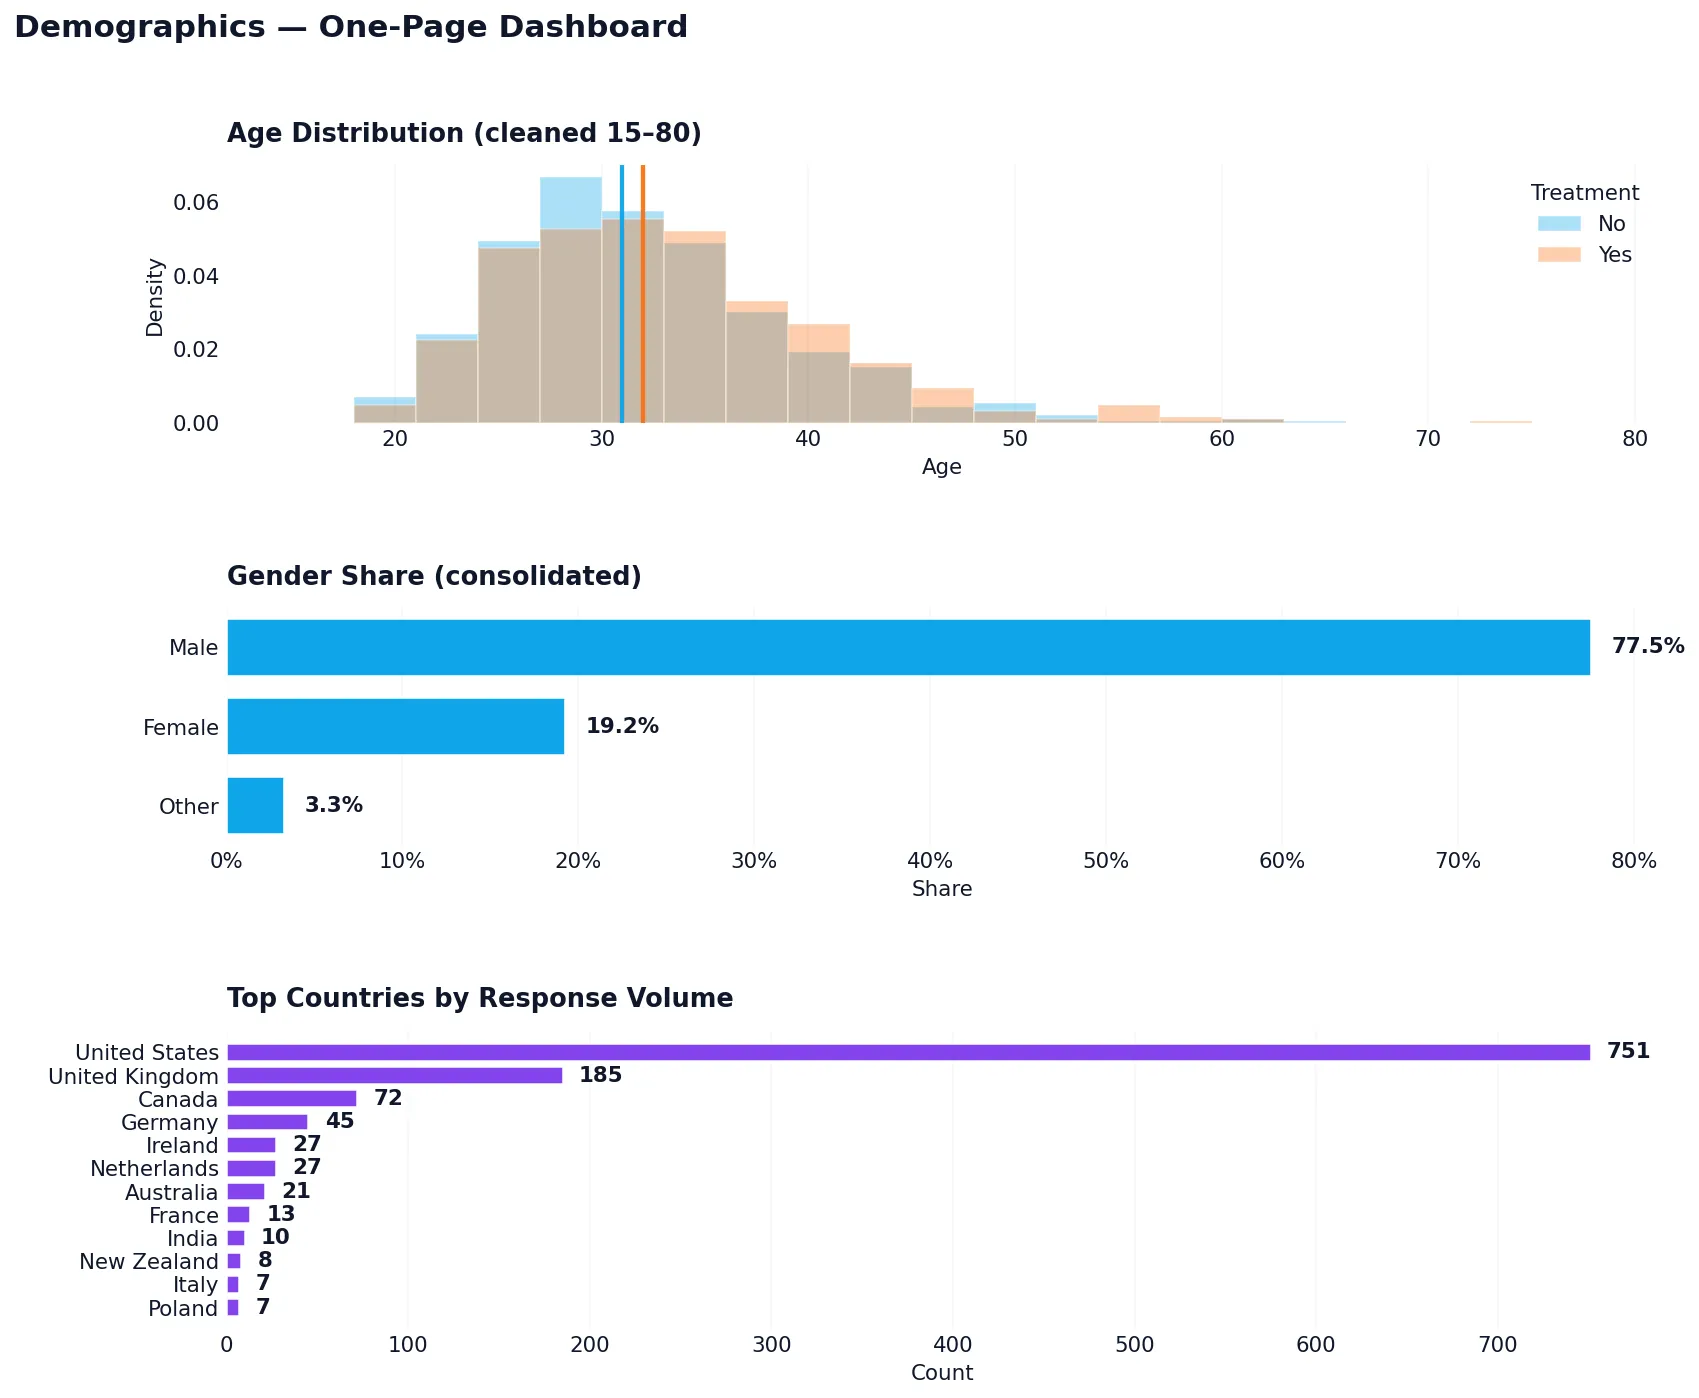
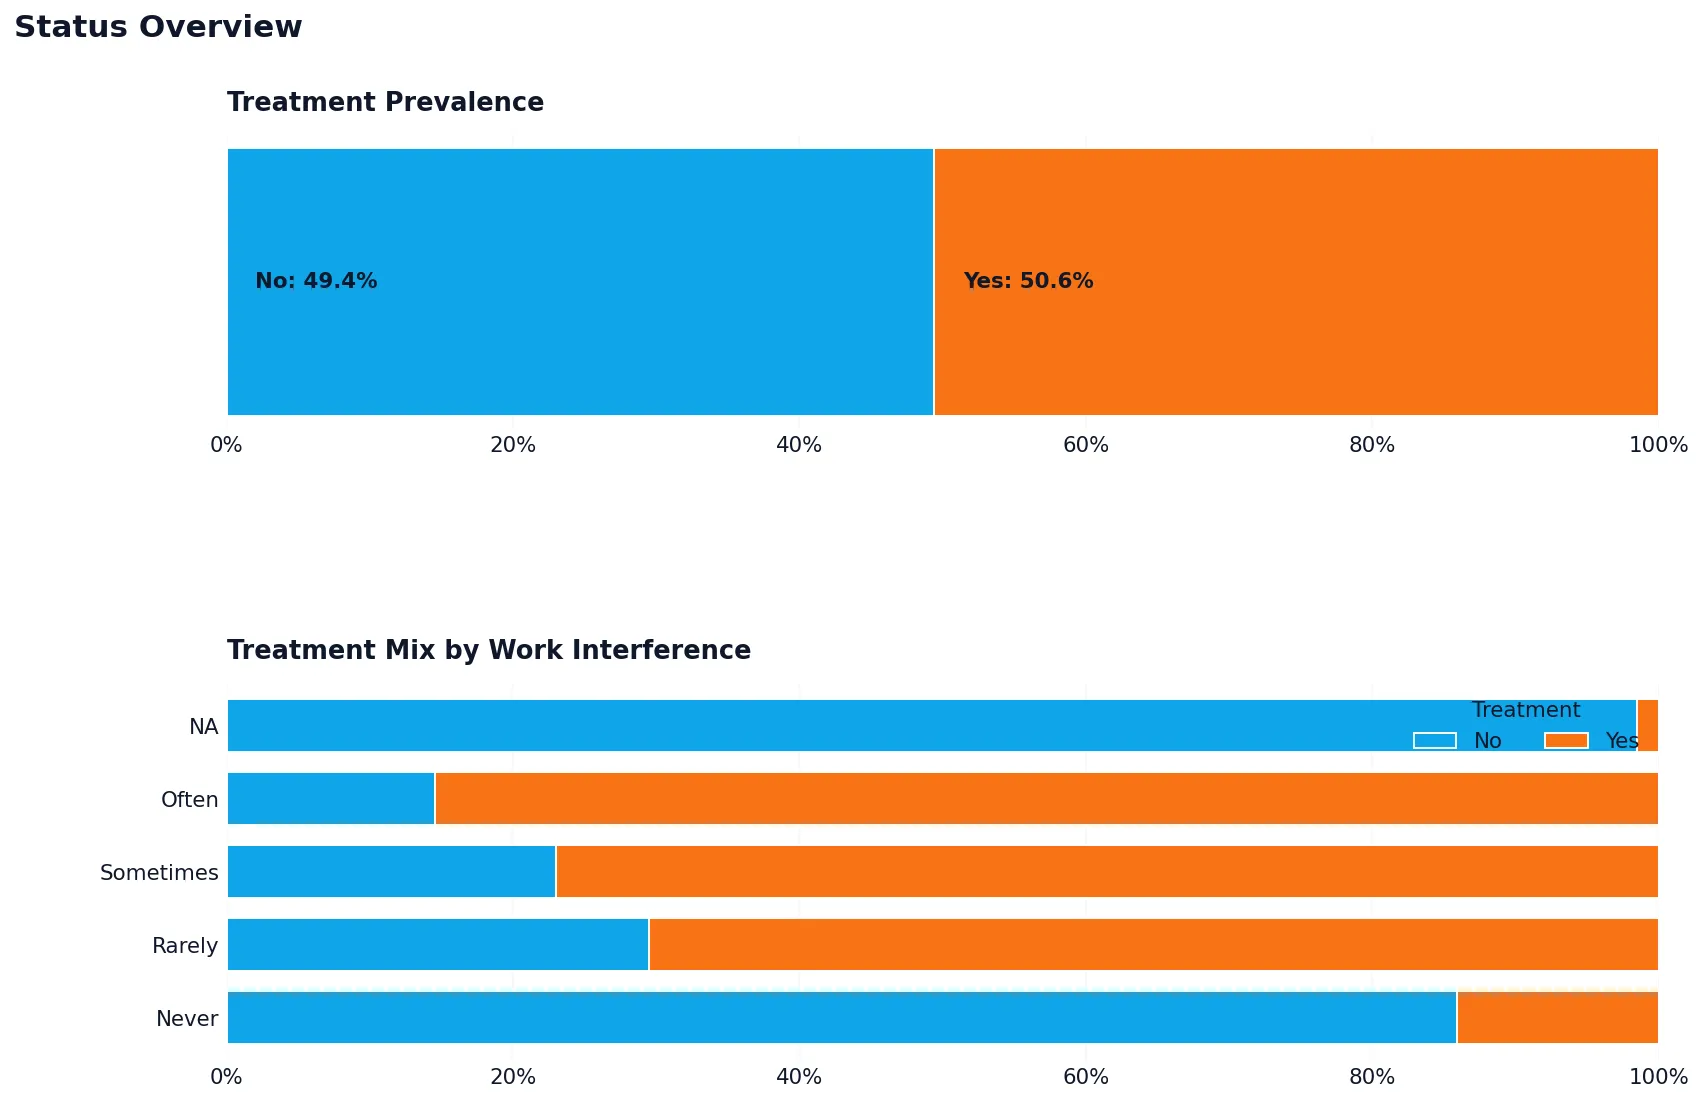
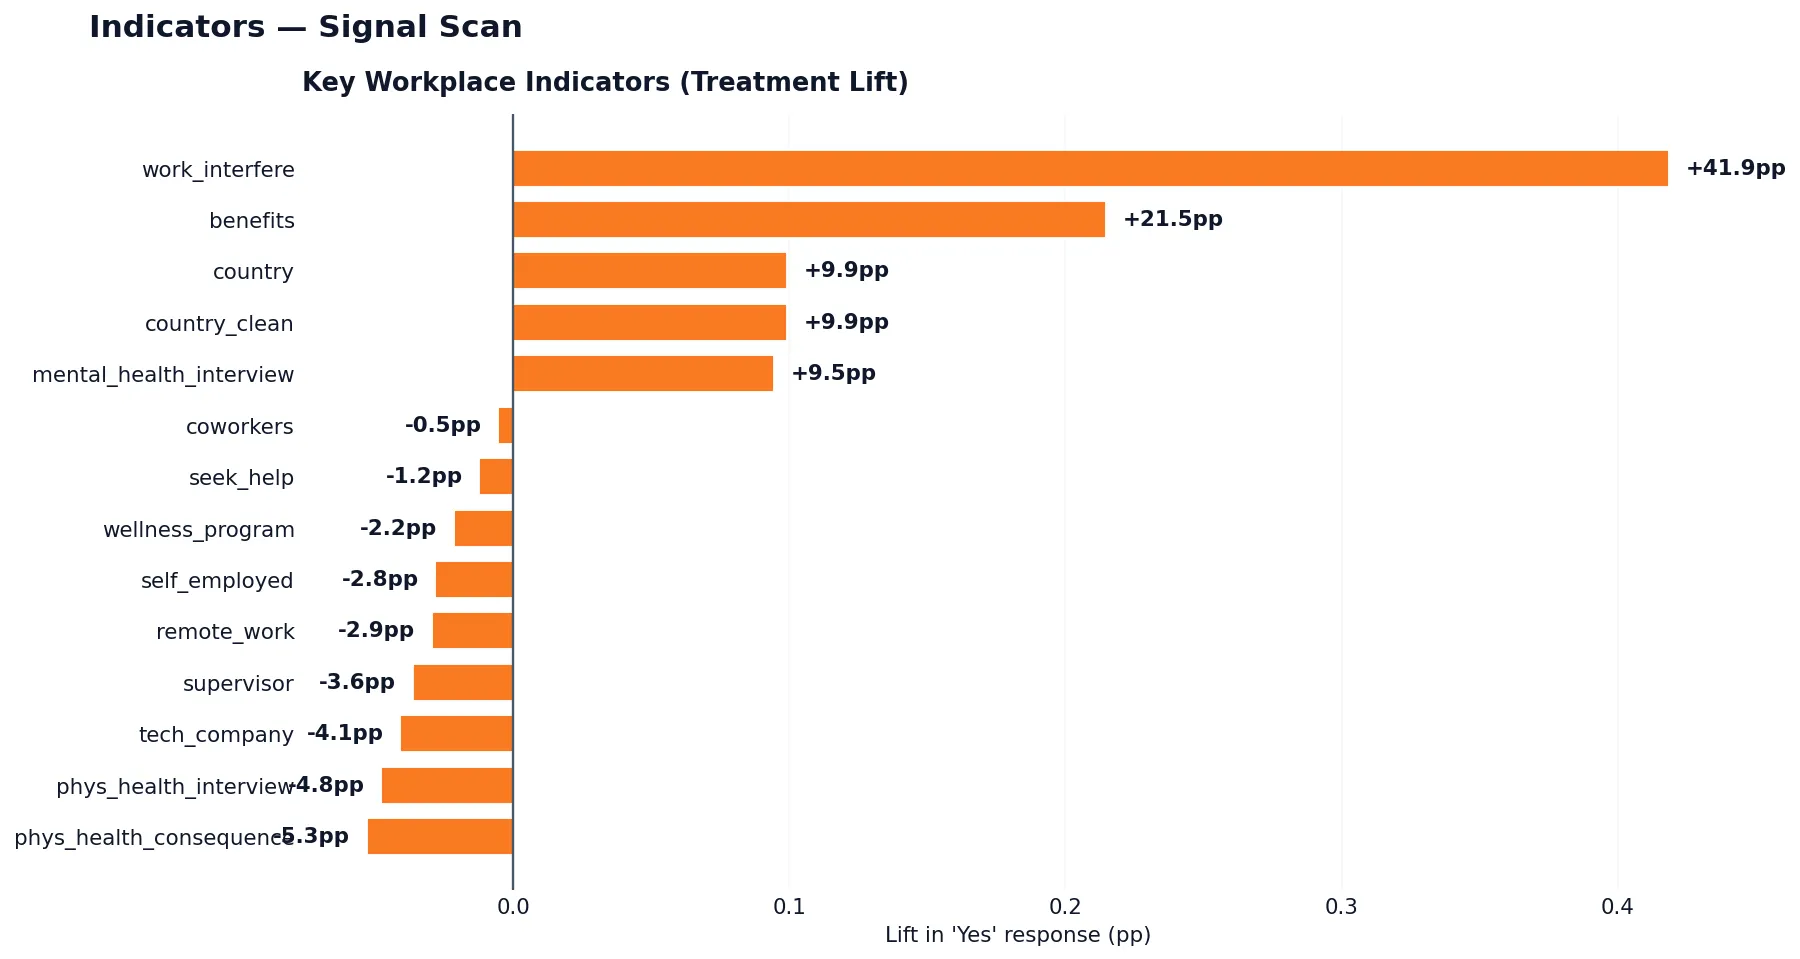
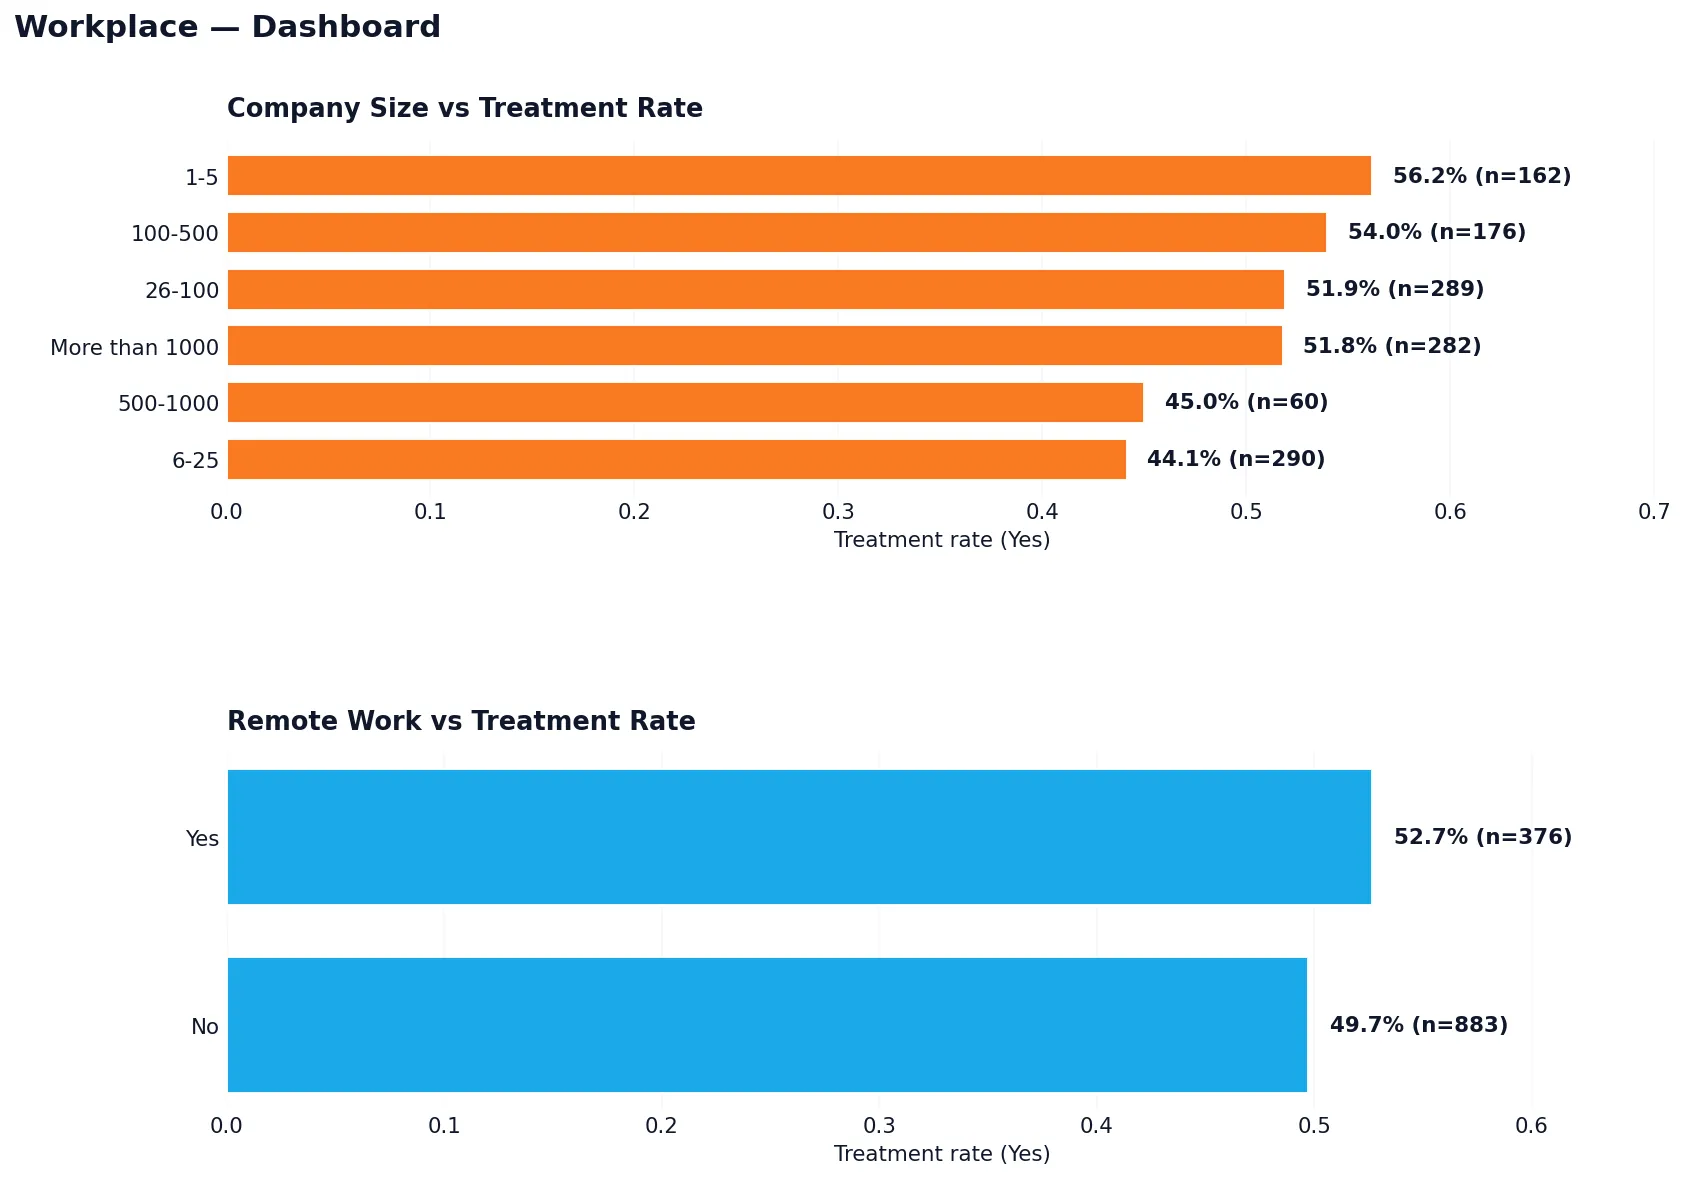
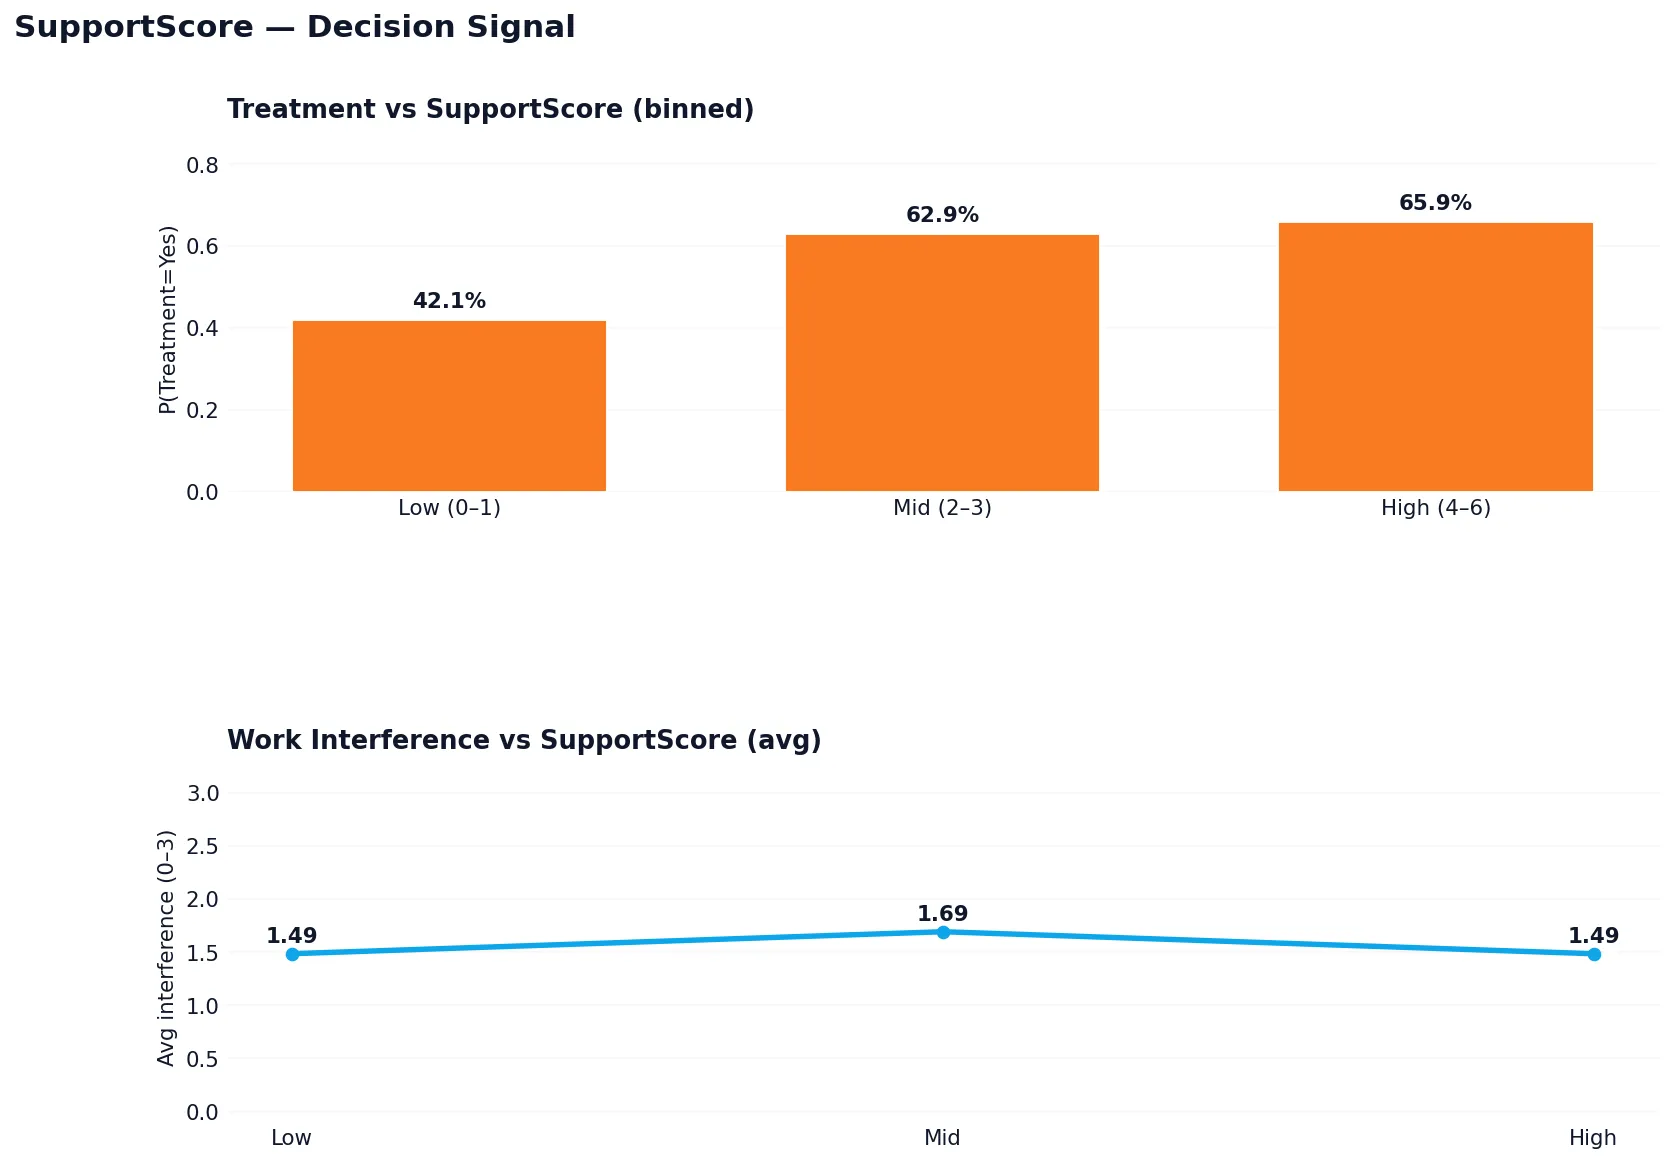
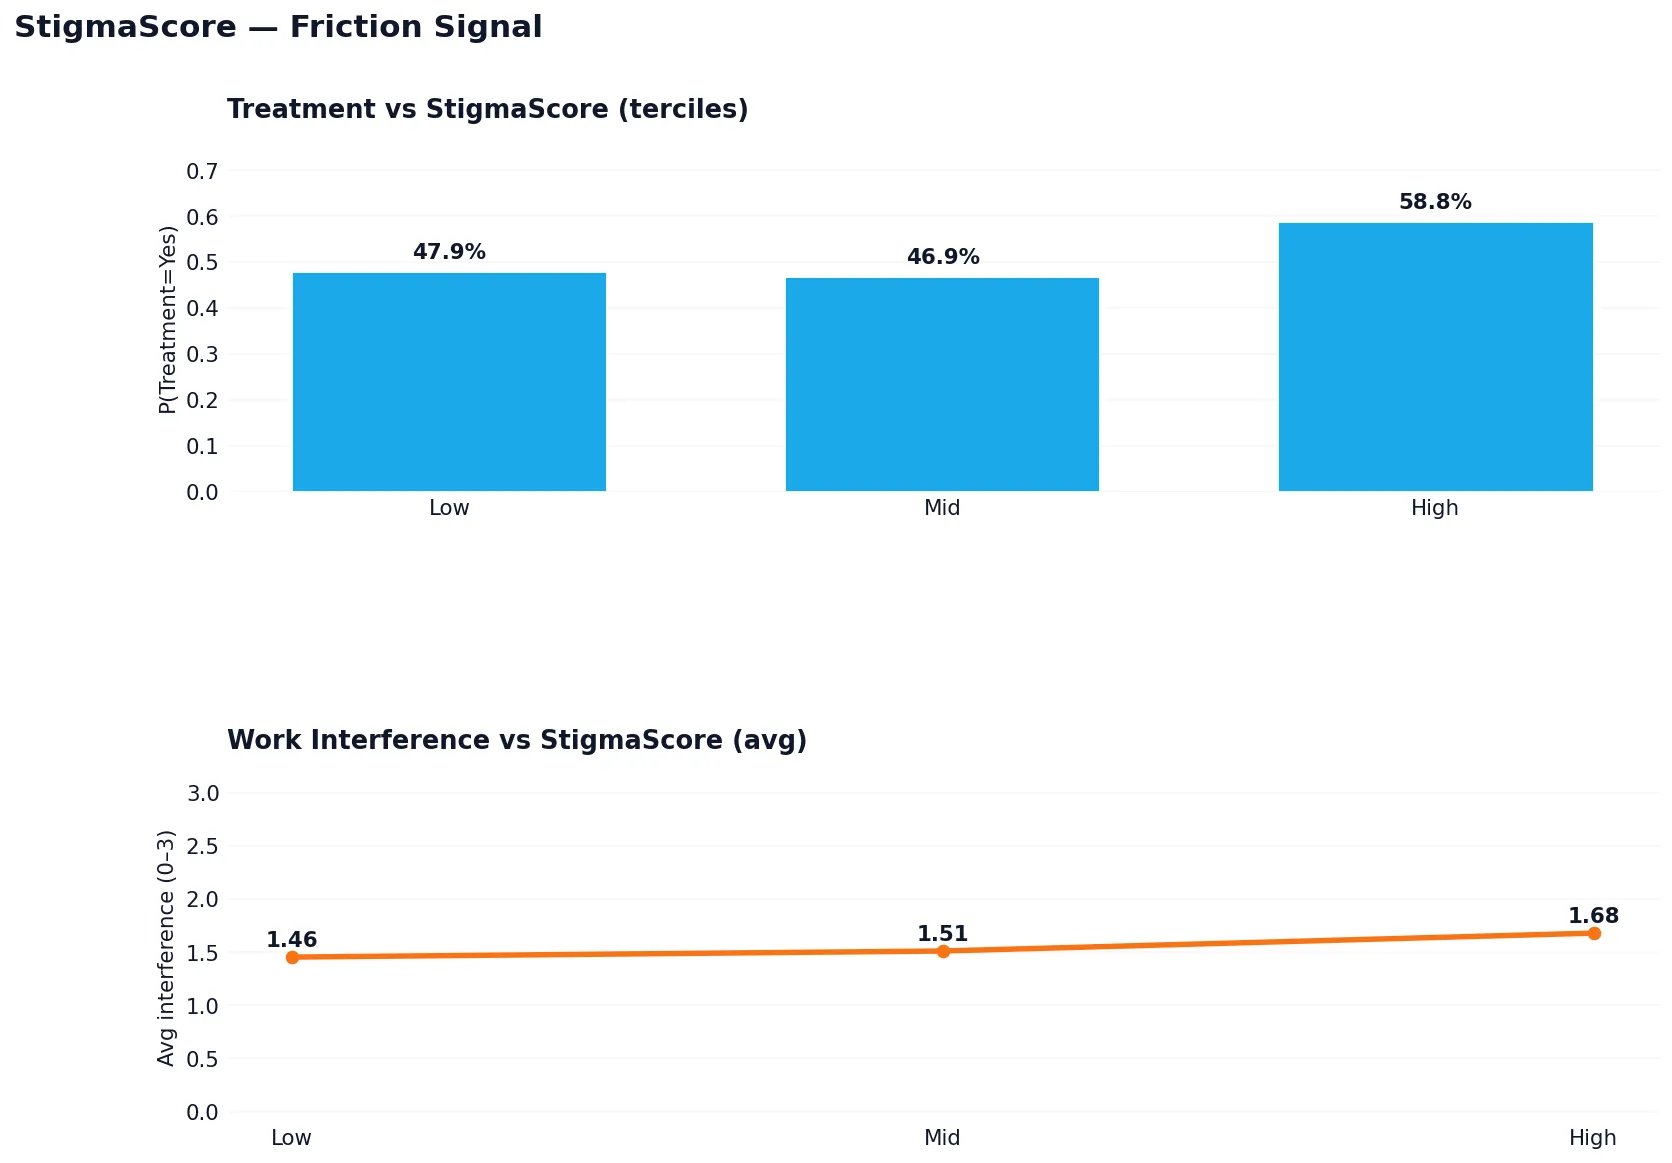

In [7]:
def yes_rate_by(col, topn=12):
    if col not in vt.columns:
        return pd.DataFrame()
    s = clean_str(vt[col]).replace("", np.nan).fillna("NA")
    tmp = pd.DataFrame({col: s, "treatment": vt["treatment"]})
    g = (tmp.groupby(col, observed=True)["treatment"].value_counts().unstack().fillna(0))
    for c in ["No","Yes"]:
        if c not in g.columns:
            g[c] = 0
    g["total"] = g["No"] + g["Yes"]
    g["yes_rate"] = (g["Yes"] / g["total"]).replace([np.inf,-np.inf], np.nan)
    g = g.sort_values("total", ascending=False).head(topn)
    return g.reset_index().rename(columns={col:"segment"})[["segment","total","yes_rate"]]

charts = []

W = 13.2
H_LONG = 10.8
DPI = 140

fig = plt.figure(figsize=(W, H_LONG))
gs = fig.add_gridspec(3, 1, height_ratios=[1.25, 1.15, 1.45], hspace=0.70)

ax1 = fig.add_subplot(gs[0,0])
if "age_clean" in vt.columns and vt["age_clean"].notna().any():
    bins = np.arange(15, 81, 3)
    a_no = vt.loc[vt["treatment"].eq("No"), "age_clean"].dropna().to_numpy()
    a_yes = vt.loc[vt["treatment"].eq("Yes"), "age_clean"].dropna().to_numpy()
    ax1.hist(a_no, bins=bins, density=True, alpha=0.35, color=THEME["blue"], edgecolor="white", linewidth=0.8, label="No")
    ax1.hist(a_yes, bins=bins, density=True, alpha=0.35, color=THEME["orange"], edgecolor="white", linewidth=0.8, label="Yes")
    if len(a_no): ax1.axvline(np.median(a_no), color=THEME["blue"], linewidth=2.2, alpha=0.95)
    if len(a_yes): ax1.axvline(np.median(a_yes), color=THEME["orange"], linewidth=2.2, alpha=0.95)
    ax1.legend(title="Treatment", frameon=False, loc="upper right")
ax1.set_title("Age Distribution (cleaned 15–80)", loc="left", fontweight="1000", pad=12)
ax1.set_xlabel("Age"); ax1.set_ylabel("Density")
ax_minimal(ax1, grid_axis="x")

ax2 = fig.add_subplot(gs[1,0])
if "gender_clean" in vt.columns:
    g = vt["gender_clean"].fillna("NA").value_counts().head(10)
    g = (g / g.sum()).sort_values()
    y = np.arange(len(g))
    ax2.barh(y, g.values, color=THEME["blue"], edgecolor="white", linewidth=0.8, height=0.72)
    ax2.set_yticks(y); ax2.set_yticklabels(g.index)
    ax2.xaxis.set_major_formatter(PercentFormatter(1.0))
    for i, p in enumerate(g.values):
        ax2.text(min(p + 0.012, 0.98), i, f"{p*100:.1f}%", va="center", fontweight="900")
ax2.set_title("Gender Share (consolidated)", loc="left", fontweight="1000", pad=12)
ax2.set_xlabel("Share"); ax2.set_ylabel("")
ax_minimal(ax2, grid_axis="x")

ax3 = fig.add_subplot(gs[2,0])
if "country_clean" in vt.columns:
    c = vt["country_clean"].fillna("NA").value_counts().head(12).sort_values()
    y = np.arange(len(c))
    ax3.barh(y, c.values, color=THEME["purple"], edgecolor="white", linewidth=0.8, alpha=0.95, height=0.72)
    ax3.set_yticks(y); ax3.set_yticklabels(c.index)
    for i, v in enumerate(c.values):
        ax3.text(v + max(c.values)*0.012, i, f"{int(v)}", va="center", fontweight="900")
ax3.set_title("Top Countries by Response Volume", loc="left", fontweight="1000", pad=12)
ax3.set_xlabel("Count"); ax3.set_ylabel("")
ax_minimal(ax3, grid_axis="x")

fig.suptitle("Demographics — One-Page Dashboard", x=0.01, ha="left", fontweight="1000", fontsize=16, y=0.98)
b64, mime = fig_to_b64(fig, dpi=DPI)
charts.append(("Demographics", b64, mime, "One page: Age + Gender + Country"))

fig = plt.figure(figsize=(W, 8.6))
gs = fig.add_gridspec(2, 1, height_ratios=[1.05, 1.35], hspace=0.75)

ax1 = fig.add_subplot(gs[0,0])
vc = vt["treatment"].value_counts().reindex(["No","Yes"]).fillna(0).astype(int)
total = int(vc.sum()) if int(vc.sum()) > 0 else 1
p_no = vc["No"]/total
p_yes = vc["Yes"]/total
ax1.barh([0], [p_no], color=THEME["blue"], edgecolor="white", height=0.62)
ax1.barh([0], [p_yes], left=[p_no], color=THEME["orange"], edgecolor="white", height=0.62)
ax1.set_xlim(0,1); ax1.set_yticks([])
ax1.set_xticks(np.linspace(0,1,6))
ax1.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0,1,6)])
ax1.text(p_no*0.04, 0, f"No: {p_no*100:.1f}%", va="center", fontweight="1000")
ax1.text(p_no + p_yes*0.04, 0, f"Yes: {p_yes*100:.1f}%", va="center", fontweight="1000")
ax1.set_title("Treatment Prevalence", loc="left", fontweight="1000", pad=12)
ax_minimal(ax1, grid_axis="x")

ax2 = fig.add_subplot(gs[1,0])
order_lbl = ["Never","Rarely","Sometimes","Often","NA"]
tmp = vt.copy()
tmp["work_interfere"] = tmp["work_interfere"].where(tmp["work_interfere"].isin(order_lbl), "NA")
g = (tmp.groupby("work_interfere", observed=True)["treatment"].value_counts().unstack().fillna(0))
for col in ["No","Yes"]:
    if col not in g.columns:
        g[col] = 0
g = g[["No","Yes"]]
g["total"] = g.sum(axis=1)
g = g.loc[[x for x in order_lbl if x in g.index]]
g["no_pct"] = (g["No"]/g["total"]).fillna(0)
g["yes_pct"] = (g["Yes"]/g["total"]).fillna(0)
y = np.arange(len(g))
ax2.barh(y, g["no_pct"], color=THEME["blue"], edgecolor="white", label="No", height=0.72)
ax2.barh(y, g["yes_pct"], left=g["no_pct"], color=THEME["orange"], edgecolor="white", label="Yes", height=0.72)
ax2.set_yticks(y); ax2.set_yticklabels(g.index)
ax2.set_xlim(0,1)
ax2.set_xticks(np.linspace(0,1,6))
ax2.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0,1,6)])
ax2.set_title("Treatment Mix by Work Interference", loc="left", fontweight="1000", pad=12)
ax_minimal(ax2, grid_axis="x")
ax2.legend(title="Treatment", frameon=False, ncol=2, loc="upper right")

fig.suptitle("Status Overview", x=0.01, ha="left", fontweight="1000", fontsize=16, y=0.98)
b64, mime = fig_to_b64(fig, dpi=DPI)
charts.append(("Status", b64, mime, "Prevalence + interference mix"))

fig, ax = plt.subplots(figsize=(W, 7.2))
cat_cols = [c for c in vt.columns if (vt[c].dtype == "object" or str(vt[c].dtype) == "string") and c not in ["treatment"]]
rows = []
min_segment = 25
for col in cat_cols:
    s = clean_str(vt[col]).replace("", np.nan).fillna("NA")
    if s.empty:
        continue
    top_level = s.value_counts(dropna=False).index[0]
    m = (s == top_level)
    if int(m.sum()) < min_segment or int((~m).sum()) < min_segment:
        continue
    p_yes_t = (vt.loc[m, "treatment"] == "Yes").mean()
    p_yes_c = (vt.loc[~m, "treatment"] == "Yes").mean()
    rows.append({"feature": col, "lift_pp": (p_yes_t - p_yes_c)*100.0})

lift = pd.DataFrame(rows)
if lift.empty:
    ax.text(0.5, 0.5, "Insufficient segment sizes to compute lift.", ha="center", va="center", fontweight="1000")
    ax.axis("off")
else:
    lift = lift.sort_values("lift_pp", ascending=False).head(14).sort_values("lift_pp", ascending=True)
    y = np.arange(len(lift))
    ax.axvline(0, color=THEME["gray"], linewidth=1.2)
    vals = lift["lift_pp"].to_numpy()/100.0
    ax.barh(y, vals, color=THEME["orange"], edgecolor="white", alpha=0.95, height=0.72)
    ax.set_yticks(y); ax.set_yticklabels(lift["feature"])
    ax.set_title("Key Workplace Indicators (Treatment Lift)", loc="left", fontweight="1000", pad=12)
    ax.set_xlabel("Lift in 'Yes' response (pp)")
    for i, pp in enumerate(lift["lift_pp"].to_numpy()):
        ax.text((pp/100.0) + (0.006 if pp >= 0 else -0.006), i, f"{pp:+.1f}pp",
                va="center", ha=("left" if pp >= 0 else "right"), fontweight="900")
    ax_minimal(ax, grid_axis="x")

fig.suptitle("Indicators — Signal Scan", x=0.01, ha="left", fontweight="1000", fontsize=16, y=0.98)
b64, mime = fig_to_b64(fig, dpi=DPI)
charts.append(("Indicators", b64, mime, "Signal scan: lift (pp)"))

fig = plt.figure(figsize=(W, 9.0))
gs = fig.add_gridspec(2, 1, hspace=0.72)

ax1 = fig.add_subplot(gs[0,0])
cs = yes_rate_by("no_employees", topn=12)
if not cs.empty:
    cs = cs.sort_values("yes_rate")
    y = np.arange(len(cs))
    ax1.barh(y, cs["yes_rate"], color=THEME["orange"], edgecolor="white", alpha=0.95, height=0.72)
    ax1.set_yticks(y); ax1.set_yticklabels(cs["segment"])
    ax1.set_xlim(0, min(1.0, max(float(cs["yes_rate"].max())*1.25, 0.30)))
    for i, (p, n) in enumerate(zip(cs["yes_rate"], cs["total"])):
        ax1.text(p + 0.01, i, f"{p*100:.1f}% (n={int(n)})", va="center", fontweight="900")
ax1.set_title("Company Size vs Treatment Rate", loc="left", fontweight="1000", pad=12)
ax1.set_xlabel("Treatment rate (Yes)")
ax_minimal(ax1, grid_axis="x")

ax2 = fig.add_subplot(gs[1,0])
rw = yes_rate_by("remote_work", topn=10)
if not rw.empty:
    rw = rw.sort_values("yes_rate")
    y = np.arange(len(rw))
    ax2.barh(y, rw["yes_rate"], color=THEME["blue"], edgecolor="white", alpha=0.95, height=0.72)
    ax2.set_yticks(y); ax2.set_yticklabels(rw["segment"])
    ax2.set_xlim(0, min(1.0, max(float(rw["yes_rate"].max())*1.25, 0.30)))
    for i, (p, n) in enumerate(zip(rw["yes_rate"], rw["total"])):
        ax2.text(p + 0.01, i, f"{p*100:.1f}% (n={int(n)})", va="center", fontweight="900")
ax2.set_title("Remote Work vs Treatment Rate", loc="left", fontweight="1000", pad=12)
ax2.set_xlabel("Treatment rate (Yes)")
ax_minimal(ax2, grid_axis="x")

fig.suptitle("Workplace — Dashboard", x=0.01, ha="left", fontweight="1000", fontsize=16, y=0.98)
b64, mime = fig_to_b64(fig, dpi=DPI)
charts.append(("Workplace", b64, mime, "Orange=company size, Blue=remote work"))

fig = plt.figure(figsize=(W, 9.1))
gs = fig.add_gridspec(2, 1, hspace=0.80)

ax1 = fig.add_subplot(gs[0,0])
tmp = vt.dropna(subset=["SupportScore"]).copy()
if not tmp.empty:
    tmp["support_bin"] = pd.cut(tmp["SupportScore"], bins=[-0.1,1,3,6], labels=["Low (0–1)","Mid (2–3)","High (4–6)"])
    g2 = tmp.groupby("support_bin", observed=True)["treatment"].apply(lambda x: (x=="Yes").mean()).reset_index(name="yes_rate")
    x = np.arange(len(g2))
    ax1.bar(x, g2["yes_rate"], color=THEME["orange"], edgecolor="white", alpha=0.95, width=0.64)
    ax1.set_xticks(x); ax1.set_xticklabels(g2["support_bin"])
    ax1.set_ylim(0, min(1.0, max(float(g2["yes_rate"].max())*1.30, 0.35)))
    for i, p in enumerate(g2["yes_rate"]):
        ax1.text(i, p+0.02, f"{p*100:.1f}%", ha="center", va="bottom", fontweight="1000")
ax1.set_title("Treatment vs SupportScore (binned)", loc="left", fontweight="1000", pad=12)
ax1.set_ylabel("P(Treatment=Yes)")
ax_minimal(ax1, grid_axis="y")

ax2 = fig.add_subplot(gs[1,0])
tmp2 = vt.dropna(subset=["SupportScore","work_interfere_y"]).copy()
if not tmp2.empty:
    tmp2["support_bin"] = pd.cut(tmp2["SupportScore"], bins=[-0.1,1,3,6], labels=["Low","Mid","High"])
    g3 = tmp2.groupby("support_bin", observed=True)["work_interfere_y"].mean().reset_index(name="avg_interfere")
    x = np.arange(len(g3))
    ax2.plot(x, g3["avg_interfere"], marker="o", linewidth=2.8, color=THEME["blue"])
    ax2.set_xticks(x); ax2.set_xticklabels(g3["support_bin"])
    ax2.set_ylim(-0.1, 3.2)
    for i, v in enumerate(g3["avg_interfere"]):
        ax2.text(i, v+0.10, f"{v:.2f}", ha="center", fontweight="1000")
ax2.set_title("Work Interference vs SupportScore (avg)", loc="left", fontweight="1000", pad=12)
ax2.set_ylabel("Avg interference (0–3)")
ax_minimal(ax2, grid_axis="y")

fig.suptitle("SupportScore — Decision Signal", x=0.01, ha="left", fontweight="1000", fontsize=16, y=0.98)
b64, mime = fig_to_b64(fig, dpi=DPI)
charts.append(("SupportScore", b64, mime, "Orange=treatment, Blue=interference"))

fig = plt.figure(figsize=(W, 9.1))
gs = fig.add_gridspec(2, 1, hspace=0.80)

ax1 = fig.add_subplot(gs[0,0])
tmp = vt.dropna(subset=["StigmaScore"]).copy()
if not tmp.empty:
    try:
        tmp["stigma_bin"] = pd.qcut(tmp["StigmaScore"], q=3, labels=["Low","Mid","High"])
    except Exception:
        tmp["stigma_bin"] = pd.cut(tmp["StigmaScore"], bins=3, labels=["Low","Mid","High"])
    g4 = tmp.groupby("stigma_bin", observed=True)["treatment"].apply(lambda x: (x=="Yes").mean()).reset_index(name="yes_rate")
    x = np.arange(len(g4))
    ax1.bar(x, g4["yes_rate"], color=THEME["blue"], edgecolor="white", alpha=0.95, width=0.64)
    ax1.set_xticks(x); ax1.set_xticklabels(g4["stigma_bin"])
    ax1.set_ylim(0, min(1.0, max(float(g4["yes_rate"].max())*1.30, 0.35)))
    for i, p in enumerate(g4["yes_rate"]):
        ax1.text(i, p+0.02, f"{p*100:.1f}%", ha="center", va="bottom", fontweight="1000")
ax1.set_title("Treatment vs StigmaScore (terciles)", loc="left", fontweight="1000", pad=12)
ax1.set_ylabel("P(Treatment=Yes)")
ax_minimal(ax1, grid_axis="y")

ax2 = fig.add_subplot(gs[1,0])
tmp2 = vt.dropna(subset=["StigmaScore","work_interfere_y"]).copy()
if not tmp2.empty:
    try:
        tmp2["stigma_bin"] = pd.qcut(tmp2["StigmaScore"], q=3, labels=["Low","Mid","High"])
    except Exception:
        tmp2["stigma_bin"] = pd.cut(tmp2["StigmaScore"], bins=3, labels=["Low","Mid","High"])
    g5 = tmp2.groupby("stigma_bin", observed=True)["work_interfere_y"].mean().reset_index(name="avg_interfere")
    x = np.arange(len(g5))
    ax2.plot(x, g5["avg_interfere"], marker="o", linewidth=2.8, color=THEME["orange"])
    ax2.set_xticks(x); ax2.set_xticklabels(g5["stigma_bin"])
    ax2.set_ylim(-0.1, 3.2)
    for i, v in enumerate(g5["avg_interfere"]):
        ax2.text(i, v+0.10, f"{v:.2f}", ha="center", fontweight="1000")
ax2.set_title("Work Interference vs StigmaScore (avg)", loc="left", fontweight="1000", pad=12)
ax2.set_ylabel("Avg interference (0–3)")
ax_minimal(ax2, grid_axis="y")

fig.suptitle("StigmaScore — Friction Signal", x=0.01, ha="left", fontweight="1000", fontsize=16, y=0.98)
b64, mime = fig_to_b64(fig, dpi=DPI)
charts.append(("StigmaScore", b64, mime, "Blue=treatment, Orange=interference"))

chart_tabs(charts, panel_title="Six Key Charts")

- Demographics show a predominantly mid-career, tech-company population with strong US/UK representation, which should inform how generalizable we consider the findings.

- Treatment is taken up by roughly half of respondents, with substantially higher uptake among those reporting more frequent work interference.

- Treatment rates increase with company size and are modestly higher among non-remote or hybrid workers, indicating that larger organizations may provide more accessible support routes.

- Higher SupportScore bands are associated with higher treatment uptake and lower average work interference, positioning support levers as a key mitigation tool.

- Higher StigmaScore bands show lower treatment probabilities and higher average work interference, highlighting stigma as a material source of operational friction.

# **6. Segmentation (Support × Stigma Quadrants)**

Respondents are segmented into Support × Stigma quadrants to highlight high-support / low-stigma “role model” segments versus high-risk pockets characterized by low support and high stigma.

In [8]:
seg = vt.dropna(subset=["SupportScore","StigmaScore"]).copy()
if seg.empty:
    display(HTML(f"<div style='color:{THEME['gray']};font-weight:900'>Segmentation unavailable.</div>"))
else:
    sup_med = float(seg["SupportScore"].median())
    stig_med = float(seg["StigmaScore"].median())

    seg["SupportTier"] = np.where(seg["SupportScore"] >= sup_med, "High Support", "Low Support")
    seg["StigmaTier"] = np.where(seg["StigmaScore"] >= stig_med, "High Stigma", "Low Stigma")
    seg["Quadrant"] = seg["SupportTier"] + " × " + seg["StigmaTier"]

    q = (seg.groupby("Quadrant", observed=True)
         .agg(
             n=("Quadrant","size"),
             treatment_rate=("treatment_y", "mean"),
             hi_interfere_rate=("hi_interfere_y", lambda x: float(pd.to_numeric(x, errors="coerce").mean())),
             avg_interfere=("work_interfere_y","mean"),
             avg_age=("age_clean","mean"),
             avg_support=("SupportScore","mean"),
             avg_stigma=("StigmaScore","mean"),
         )
         .reset_index())

    order = [
        "High Support × Low Stigma",
        "High Support × High Stigma",
        "Low Support × Low Stigma",
        "Low Support × High Stigma",
    ]
    q["Quadrant"] = pd.Categorical(q["Quadrant"], categories=order, ordered=True)
    q = q.sort_values("Quadrant")

    q_fmt = q.copy()
    q_fmt["treatment_rate"] = (q_fmt["treatment_rate"]*100).round(1)
    q_fmt["hi_interfere_rate"] = (q_fmt["hi_interfere_rate"]*100).round(1)
    q_fmt = q_fmt.round({"avg_interfere":2,"avg_age":1,"avg_support":2,"avg_stigma":2})

    persona = []
    for _, r in q.iterrows():
        quad = str(r["Quadrant"])
        persona.append({
            "Quadrant": quad,
            "Implication": (
                "Enablement segment (scale best practices)"
                if quad == "High Support × Low Stigma" else
                "Stigma drag despite support"
                if quad == "High Support × High Stigma" else
                "Under-instrumented but culturally OK"
                if quad == "Low Support × Low Stigma" else
                "Critical risk pocket"
            ),
            "Primary Move": (
                "Codify policies, measure utilization"
                if quad == "High Support × Low Stigma" else
                "Normalize disclosure, protect anonymity, manager enablement"
                if quad == "High Support × High Stigma" else
                "Roll out benefits/care pathways + easy leave + seek-help"
                if quad == "Low Support × Low Stigma" else
                "Rapid interventions: anonymity + consequence mitigation + manager training"
            )
        })

    df_tabs([
        ("Quadrant Scorecard", q_fmt, 2, "BlueOrange", 12),
        ("Persona Playbook", pd.DataFrame(persona), 2, "Oranges", 12),
    ], panel_title="Segmentation")

# **7. Text Analytics** 

In [9]:
text_like = []
for c in df.columns:
    if df[c].dtype == "object" or str(df[c].dtype) == "string":
        avg_len = df[c].astype("string").dropna().str.len().mean()
        if pd.notna(avg_len) and avg_len >= 35:
            text_like.append((c, round(float(avg_len),1), int(df[c].nunique(dropna=True))))

text_df = pd.DataFrame(text_like, columns=["column","avg_char_len","n_unique"]).sort_values("avg_char_len", ascending=False)
display(show_df(text_df.head(10), title="Free-Text Candidates", precision=2, cmap="Blues", max_rows=10))

,column,avg_char_len,n_unique
0,comments,243.20,160


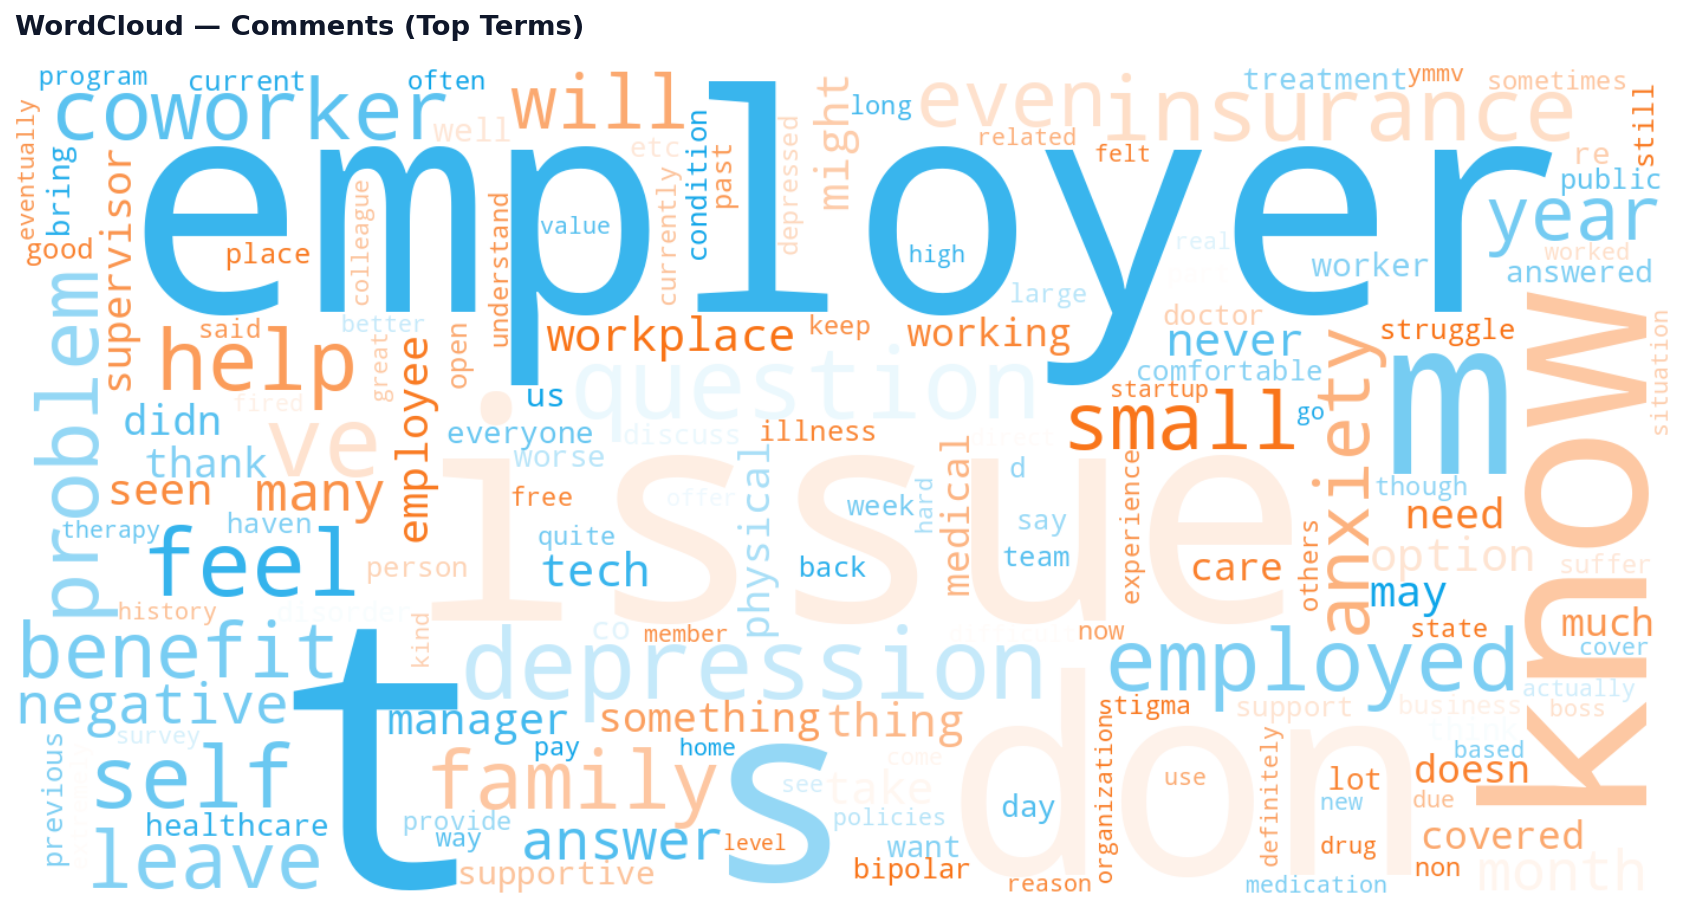

In [10]:
from wordcloud import WordCloud, STOPWORDS
from PIL import Image

if "comments" not in df.columns:
    display(HTML(f"<div style='color:{THEME['gray']};font-weight:900'>Column 'comments' not found.</div>"))
else:
    txt = df["comments"].astype("string").fillna("").str.strip()
    txt = txt[txt.str.len() > 0]
    if txt.empty:
        display(HTML(f"<div style='color:{THEME['gray']};font-weight:900'>No non-empty text available.</div>"))
    else:
        text_blob = " ".join(txt.tolist()).lower()
        text_blob = re.sub(r"http\S+|www\.\S+", " ", text_blob)
        text_blob = re.sub(r"[^a-z\s]", " ", text_blob)
        text_blob = re.sub(r"\s+", " ", text_blob).strip()

        extra_stop = {
            "mental","health","work","company","people","time","job","like","just","really","also",
            "dont","didnt","doesnt","im","ive","cant","wont","would","could","get","got","one","make",
            "yes","no"
        }
        stops = list(set(STOPWORDS).union(extra_stop))

        MASK_PATH = "mask_head_hands.png"
        mask = np.array(Image.open(MASK_PATH)) if os.path.exists(MASK_PATH) else None

        wc = WordCloud(
            width=1400,
            height=700,
            background_color="white",
            max_words=160,
            prefer_horizontal=0.92,
            min_font_size=10,
            collocations=False,
            stopwords=stops,
            colormap=CMAP_BO,
            random_state=42,
            mask=mask
        ).generate(text_blob)

        fig, ax = plt.subplots(figsize=(13.2, 6.2), dpi=150)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title("WordCloud — Comments (Top Terms)", loc="left", fontweight="1000", pad=16)
        plt.tight_layout()
        plt.show()

# **8. Predictive Modeling** 

This section builds a supervised model to predict treatment uptake, compares model families, and quantifies the relative impact of key drivers such as work interference, family history, and support levers.

In [11]:
model_df = vt.copy()

keep_cols = [
    "age_clean","gender_clean","self_employed","family_history","work_interfere",
    "no_employees","remote_work","tech_company",
    "benefits","care_options","wellness_program","seek_help","anonymity","leave",
    "mental_health_consequence","phys_health_consequence","coworkers","supervisor",
    "mental_health_interview","phys_health_interview","mental_vs_physical","obs_consequence",
    "SupportScore","StigmaScore","country_clean"
]
keep_cols = [c for c in keep_cols if c in model_df.columns]
model_df = model_df[keep_cols + ["treatment_y"]].copy()
model_df = model_df.dropna(subset=["treatment_y"]).copy()
y = model_df["treatment_y"].astype(int)

gender_cols = ["Female","Male","Other","NA"]
self_employed_cols = ["No","Yes","NA"]
family_history_cols = ["No","Yes","NA"]
work_interfere_cols = ["Never","Rarely","Sometimes","Often","NA"]
no_employees_cols = ["1-5","6-25","26-100","100-500","500-1000","More than 1000","NA"]
remote_work_cols = ["No","Yes","NA"]
tech_company_cols = ["No","Yes","NA"]
benefits_cols = ["No","Don't know","Yes","NA"]
care_options_cols = ["No","Not sure","Yes","NA"]
wellness_program_cols  = ["No","Don't know","Yes","NA"]
seek_help_cols = ["No","Don't know","Yes","NA"]
anonymity_cols = ["No","Don't know","Yes","NA"]
leave_cols = ["Very easy","Somewhat easy","Don't know","Somewhat difficult","Very difficult","NA"]
mental_health_consequence_cols = ["No","Maybe","Yes","NA"]
phys_health_consequence_cols = ["No","Maybe","Yes","NA"]
coworkers_cols = ["No","Some of them","Yes","NA"]
supervisor_cols = ["No","Some of them","Yes","NA"]
mental_health_interview_cols = ["No","Maybe","Yes","NA"]
phys_health_interview_cols = ["No","Maybe","Yes","NA"]
mental_vs_physical_cols = ["Don't know","No","Yes","NA"]
obs_consequence_cols = ["No","Yes","NA"]

ord_cols = [
    "gender_clean","self_employed","family_history","work_interfere","no_employees","remote_work","tech_company",
    "benefits","care_options","wellness_program","seek_help","anonymity","leave",
    "mental_health_consequence","phys_health_consequence","coworkers","supervisor",
    "mental_health_interview","phys_health_interview","mental_vs_physical","obs_consequence",
]
ord_cols = [c for c in ord_cols if c in model_df.columns]

ord_cats = []
for c in ord_cols:
    if c == "gender_clean": ord_cats.append(gender_cols)
    elif c == "self_employed": ord_cats.append(self_employed_cols)
    elif c == "family_history": ord_cats.append(family_history_cols)
    elif c == "work_interfere": ord_cats.append(work_interfere_cols)
    elif c == "no_employees": ord_cats.append(no_employees_cols)
    elif c == "remote_work": ord_cats.append(remote_work_cols)
    elif c == "tech_company": ord_cats.append(tech_company_cols)
    elif c == "benefits": ord_cats.append(benefits_cols)
    elif c == "care_options": ord_cats.append(care_options_cols)
    elif c == "wellness_program": ord_cats.append(wellness_program_cols)
    elif c == "seek_help": ord_cats.append(seek_help_cols)
    elif c == "anonymity": ord_cats.append(anonymity_cols)
    elif c == "leave": ord_cats.append(leave_cols)
    elif c == "mental_health_consequence": ord_cats.append(mental_health_consequence_cols)
    elif c == "phys_health_consequence": ord_cats.append(phys_health_consequence_cols)
    elif c == "coworkers": ord_cats.append(coworkers_cols)
    elif c == "supervisor": ord_cats.append(supervisor_cols)
    elif c == "mental_health_interview": ord_cats.append(mental_health_interview_cols)
    elif c == "phys_health_interview": ord_cats.append(phys_health_interview_cols)
    elif c == "mental_vs_physical": ord_cats.append(mental_vs_physical_cols)
    elif c == "obs_consequence": ord_cats.append(obs_consequence_cols)
    else: ord_cats.append(["NA"])

num_cols = [c for c in ["age_clean","SupportScore","StigmaScore"] if c in model_df.columns]
ohe_cols = [c for c in ["country_clean"] if c in model_df.columns]

X = model_df[num_cols + ord_cols + ohe_cols].copy()
for c in ord_cols + ohe_cols:
    X[c] = clean_str(X[c]).replace("", np.nan).fillna("NA")

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

num_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

ord_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=ord_cats, handle_unknown="use_encoded_value", unknown_value=np.nan)),
    ("imp2", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

ohe_pipe = Pipeline(steps=[
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore"))
])

prep = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("ord", ord_pipe, ord_cols),
        ("ohe", ohe_pipe, ohe_cols),
    ],
    remainder="drop"
)

logit = LogisticRegression(max_iter=5000, class_weight="balanced", solver="saga")
hgb = HistGradientBoostingClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gdb = GradientBoostingClassifier(random_state=42)

pipe_logit = Pipeline(steps=[("prep", prep), ("clf", logit)])
pipe_hgb = Pipeline(steps=[("prep", prep), ("clf", hgb)])
pipe_rf = Pipeline(steps=[("prep", prep), ("clf", rf)])
pipe_gdb = Pipeline(steps=[("prep", prep), ("clf", gdb)])

scoring = {"roc_auc":"roc_auc", "pr_auc":"average_precision", "f1":"f1", "recall":"recall"}

param_logit = {
    "clf__penalty": ["elasticnet"],
    "clf__C": [0.03, 0.06, 0.10, 0.20, 0.50, 1.0],
    "clf__l1_ratio": [0.15, 0.35, 0.55, 0.75],
}

param_hgb = {
    "clf__learning_rate": [0.03, 0.06, 0.10],
    "clf__max_depth": [2, 3, None],
    "clf__max_leaf_nodes": [15, 31, 63],
    "clf__min_samples_leaf": [10, 20, 40],
}

search_logit = GridSearchCV(pipe_logit, param_grid=param_logit, cv=cv, scoring="average_precision", n_jobs=-1, refit=True)
search_hgb = GridSearchCV(pipe_hgb, param_grid=param_hgb, cv=cv, scoring="average_precision", n_jobs=-1, refit=True)

search_logit.fit(X, y)
search_hgb.fit(X, y)

best_logit = search_logit.best_estimator_
best_hgb = search_hgb.best_estimator_

def cv_row(est, name):
    out = cross_validate(est, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        "Model": name,
        "CV_ROC_AUC": float(np.mean(out["test_roc_auc"])),
        "CV_PR_AUC": float(np.mean(out["test_pr_auc"])),
        "CV_F1": float(np.mean(out["test_f1"])),
        "CV_Recall": float(np.mean(out["test_recall"])),
    }

rows = []
rows.append({**cv_row(best_logit, "ElasticNet LogisticReg (tuned)"),
             "Best_C": float(search_logit.best_params_.get("clf__C")),
             "Best_l1_ratio": float(search_logit.best_params_.get("clf__l1_ratio"))})

rows.append({**cv_row(best_hgb, "HistGradientBoosting (tuned)"),
             "Best_lr": float(search_hgb.best_params_.get("clf__learning_rate")),
             "Best_depth": str(search_hgb.best_params_.get("clf__max_depth")),
             "Best_leaf_nodes": int(search_hgb.best_params_.get("clf__max_leaf_nodes"))})

score_df = pd.DataFrame(rows).sort_values(["CV_PR_AUC","CV_ROC_AUC"], ascending=False).reset_index(drop=True)
display(show_df(score_df.round(4), title="Model Scorecard", precision=4, cmap="BlueOrange", max_rows=10))

best_model = best_hgb if score_df.loc[0,"Model"].startswith("Hist") else best_logit
best_name = score_df.loc[0,"Model"]

,Model,CV_ROC_AUC,CV_PR_AUC,CV_F1,CV_Recall,Best_C,Best_l1_ratio,Best_lr,Best_depth,Best_leaf_nodes
0,HistGradientBoosting (tuned),0.9034,0.8840,0.8453,0.9137,nan,nan,0.1000,2,15.0000
1,ElasticNet LogisticReg (tuned),0.7744,0.7716,0.7175,0.7080,0.0600,0.1500,nan,nan,nan


The tuned gradient boosting model delivers strong discrimination (CV ROC-AUC ≈ 0.90) with high recall, suitable for identifying at-risk segments rather than hard individual decisions.

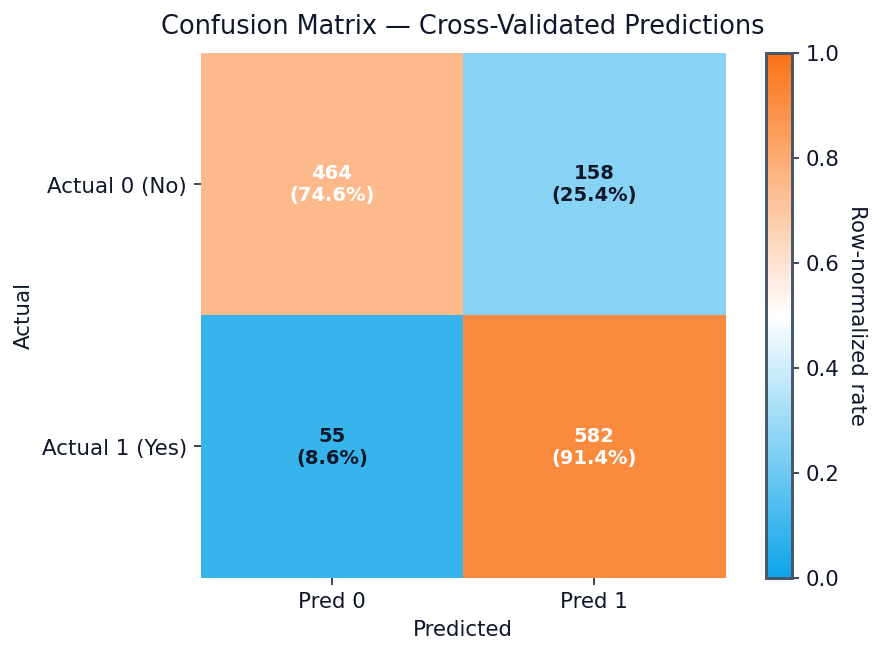

In [13]:
from sklearn.metrics import confusion_matrix

proba_cv = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
pred_cv = (proba_cv >= 0.5).astype(int)

cm = confusion_matrix(y, pred_cv)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=140)

im = ax.imshow(cm_norm, interpolation="nearest", cmap=CMAP_BO, vmin=0, vmax=1)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm_norm[i, j] * 100
        txt = f"{cm[i, j]}\n({pct:.1f}%)"
        ax.text(
            j,
            i,
            txt,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="900" if pct > 50 else "600",
            color=THEME["slate"] if pct < 70 else "#FFFFFF"
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Actual 0 (No)", "Actual 1 (Yes)"])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Cross-Validated Predictions", pad=10)

ax.set_aspect("equal")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.05)
cbar.outline.set_edgecolor(THEME["gray"])
cbar.outline.set_linewidth(1.5)
cbar.ax.set_ylabel("Row-normalized rate", rotation=270, labelpad=14)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

The model captures most positive cases (few false negatives) while maintaining a manageable false-positive rate, which is acceptable for segment-level risk flagging.

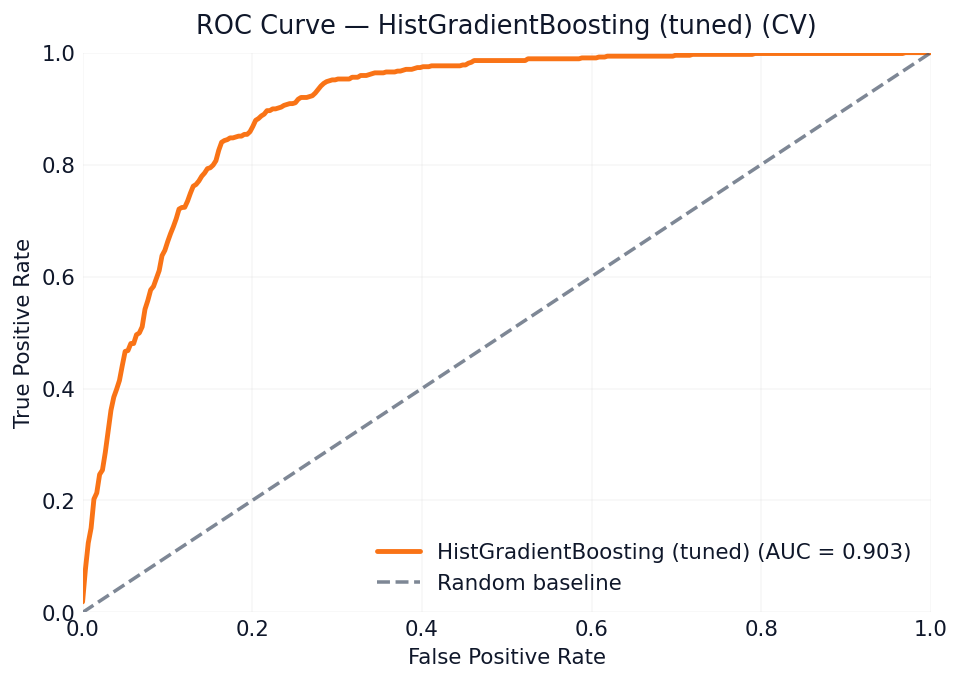

In [14]:
proba = cross_val_predict(best_model, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

fpr, tpr, _ = roc_curve(y, proba)
roc_auc = auc(fpr, tpr)

fpr_grid = np.linspace(0, 1, 300)
tpr_smooth = np.interp(fpr_grid, fpr, tpr)

fig, ax = plt.subplots(figsize=(7.0, 5.0), dpi=140)

ax.plot(
    fpr_grid,
    tpr_smooth,
    linewidth=2.5,
    color=THEME["orange"],
    solid_capstyle="round",
    label=f"{best_name} (AUC = {roc_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.8,
    color=THEME["gray"],
    alpha=0.7,
    label="Random baseline"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {best_name} (CV)", loc="center", pad=10)

ax.legend(frameon=False, loc="lower right")
ax_minimal(ax, grid_axis="both")

plt.tight_layout()
plt.show()

In [15]:
def top_logit_drivers(est, X, y, topk=18):
    est.fit(X, y)
    prep_ = est.named_steps["prep"]
    clf_ = est.named_steps["clf"]
    names = []
    names += num_cols
    names += ord_cols
    if ohe_cols:
        oh = prep_.named_transformers_["ohe"].named_steps["oh"]
        names += oh.get_feature_names_out(ohe_cols).tolist()
    coefs = clf_.coef_.ravel()
    out = pd.DataFrame({"feature": names, "coef": coefs})
    out["odds_ratio"] = np.exp(out["coef"])
    out["abs_coef"] = out["coef"].abs()
    out = out.sort_values("abs_coef", ascending=False).head(topk).drop(columns=["abs_coef"])
    return out

def top_perm_importance(est, X, y, topk=18, n_repeats=20):
    est.fit(X, y)
    Xp = est.named_steps["prep"].transform(X)
    clf_ = est.named_steps["clf"]
    names = []
    if num_cols:
        names += num_cols
    if ord_cols:
        names += ord_cols
    if ohe_cols:
        oh = est.named_steps["prep"].named_transformers_["ohe"].named_steps["oh"]
        names += oh.get_feature_names_out(ohe_cols).tolist()
    r = permutation_importance(
        clf_, Xp, y,
        n_repeats=n_repeats,
        random_state=42,
        scoring="roc_auc"
    )
    out = pd.DataFrame({
        "feature": names,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False).head(topk)
    return out

clf = best_model.named_steps["clf"]

if isinstance(clf, LogisticRegression):
    drivers = top_logit_drivers(best_model, X, y, topk=18).round({"coef":4,"odds_ratio":3})
    display(show_df(drivers, title="Top Drivers (Logistic)", precision=4, cmap="Oranges", max_rows=18))
else:
    imp = top_perm_importance(best_model, X, y, topk=18, n_repeats=15).round({"importance_mean":5,"importance_std":5})
    display(show_df(imp, title="Top Drivers (Permutation Importance, ROC-AUC)", precision=5, cmap="BlueOrange", max_rows=18))

,feature,importance_mean,importance_std
6,work_interfere,0.28906,0.01689
5,family_history,0.02030,0.00361
11,care_options,0.01173,0.00181
3,gender_clean,0.00666,0.00186
10,benefits,0.00655,0.00131
18,coworkers,0.00556,0.00123
0,age_clean,0.00496,0.00123
68,country_clean_United Kingdom,0.00348,0.00110
7,no_employees,0.00314,0.00055
2,StigmaScore,0.00291,0.00059


# **9. Strategic Recommendations**

Analytics are translated into an action-oriented roadmap across policy, leadership behavior, trust/anonymity, and operational monitoring of high work-interference segments.

In [16]:
recs = [
    {"Workstream":"Policy Instrumentation",
     "Action":"Standardize benefits/care pathways; document leave policy; publish seek-help resources",
     "Metric":"SupportScore ↑, utilization ↑",
     "Owner":"People Ops"},
    {"Workstream":"Stigma Reduction",
     "Action":"Manager enablement + leader modeling; normalize 'mental=physical' narrative",
     "Metric":"StigmaScore ↓, disclosure safety ↑",
     "Owner":"HRBP + Leadership"},
    {"Workstream":"Protection & Trust",
     "Action":"Strengthen anonymity + mitigate perceived consequences (obs_consequence)",
     "Metric":"Anonymity Yes ↑, consequence Yes ↓",
     "Owner":"Compliance + People Ops"},
    {"Workstream":"Operational Monitoring",
     "Action":"Track high work-interference as operational risk; intervene proactively",
     "Metric":"High-interference rate ↓",
     "Owner":"Org Effectiveness"},
]

display(show_df(pd.DataFrame(recs), title="Action Plan (Executive Ready)", precision=2, cmap="BlueOrange", max_rows=20))

,Workstream,Action,Metric,Owner
0,Policy Instrumentation,Standardize benefits/care pathways; document leave policy; publish seek-help resources,"SupportScore ↑, utilization ↑",People Ops
1,Stigma Reduction,Manager enablement + leader modeling; normalize 'mental=physical' narrative,"StigmaScore ↓, disclosure safety ↑",HRBP + Leadership
2,Protection & Trust,Strengthen anonymity + mitigate perceived consequences (obs_consequence),"Anonymity Yes ↑, consequence Yes ↓",Compliance + People Ops
3,Operational Monitoring,Track high work-interference as operational risk; intervene proactively,High-interference rate ↓,Org Effectiveness


### Limitations & Usage Considerations

• This is a cross-sectional survey analysis. Insights indicate associations, not strict causality.  
• Responses are self-reported and may contain perception bias, recall bias, or social desirability bias.  
• Country and demographic representation is uneven; results should not be assumed globally uniform.  
• The predictive model is intended for **segment-level decision-support**, not individual employee decision-making.  
• Any policy or organizational change should be interpreted alongside qualitative context, leadership input, and HR governance.

# **10. Governance**

This section documents notebook scope, modelling choices, and footprint constraints to keep the analysis reproducible and governance-ready.

In [17]:
gov = pd.DataFrame([{
    "charts_budget": "6 charts (tabs)",
    "theme": "single (blue+orange primary)",
    "tables": "selectable + gradient (slim previews)",
    "ml": "HistGradientBoosting (tuned) + 5-fold CV + permutation importance",
    "footprint_note": "Use webp where supported; keep sample rows small"
}])

display(show_df(gov, title="Notebook Governance Controls", precision=2, cmap="BlueOrange", max_rows=5))

,charts_budget,theme,tables,ml,footprint_note
0,6 charts (tabs),single (blue+orange primary),selectable + gradient (slim previews),HistGradientBoosting (tuned) + 5-fold CV + permutation importance,Use webp where supported; keep sample rows small


<div style="
  background: linear-gradient(to right, #f8fafc, #f1f5f9);
  padding: 25px;
  border-radius: 12px;
  color: #0f172a;
  font-family: 'Segoe UI', Roboto, Arial, sans-serif;
  font-size: 16px;
  line-height: 1.7;
  box-shadow: 0 4px 15px rgba(15,23,42,0.1);
  margin-top: 30px;
  border: 1px solid #cbd5e1;
">

  <h2 style="color: #0284c7; margin-top: 0; display: flex; align-items: center; gap: 10px;">
    🧠 Support & Feedback
  </h2>

  <p>
    If this <strong>OSMI Tech Mental Health</strong> notebook helped you explore
    <strong>SupportScore</strong>, <strong>StigmaScore</strong>, workplace dynamics,
    or inspired your own analytics journey, you can support this work by:
  </p>

  <ul style="list-style-type: none; padding-left: 5px;">
    <li style="margin-bottom: 10px;">⭐ <strong>Upvoting</strong> the notebook to increase its visibility for the data & mental-health research community</li>
    <li style="margin-bottom: 10px;">💬 <strong>Leaving a comment</strong> — share insights, ideas, or perspectives on mental health analytics</li>
    <li style="margin-bottom: 10px;">🔁 <strong>Forking</strong> the project to extend KPI dashboards, segmentation, modeling, or add new analytical lenses</li>
  </ul>

  <p>
    Your engagement helps strengthen open, data-driven understanding of
    <strong>mental health in tech workplaces</strong> and encourages better decision-support analytics.
  </p>

  <blockquote style="
    background-color: #ecfeff;
    border-left: 5px solid #0ea5e9;
    padding: 15px 20px;
    margin-top: 20px;
    font-style: italic;
    color: #075985;
    border-radius: 0 8px 8px 0;">
    Analyze thoughtfully, communicate responsibly, and keep mental well-being at the center of every insight. 📊💙
  </blockquote>

</div>